# AI Productivity: When AI Enters the Workflow

**Research question:** Beyond which threshold of AI usage does rework erode operational margins?

## Table of Contents

1. [Setup & Imports](#setup--imports)
2. [Data Loading](#data-loading)
3. [Preliminary EDA](#preliminary-eda)
4. [Data Cleaning](#data-cleaning)
5. [Multivariate EDA](#multivariate-eda)
6. [Feature Engineering](#feature-engineering)
7. [Post-Engineering Analysis](#post-engineering-analysis)
8. [Modeling](#modeling)
9. [Business Insights & Decision](#business-insights--decision)

## 1. Setup & Imports

We import the essential libraries for data manipulation, visualization, and statistical analysis. We set a random seed for reproducibility.

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)


-------
## 2. Data Loading

We load the CSV provided by Alkemy and perform a first inspection of its structure: dimensions, column names, data types, and a preview of the first rows.

In [222]:
df = pd.read_csv('ai_productivity_dataset_final.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()

Shape: 3248 rows × 34 columns

Column names:
['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at', 'delivered_at', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


-----
## 3. Preliminary EDA

The goal of this section is to understand what is in the raw data **before any cleaning**. We inspect data types, missing values, duplicates, distributions, outliers, and logical consistency issues. Every finding here will justify a specific cleaning decision in the next section.

### 3.1 — General Audit

We build a summary table showing, for each column: data type, number of missing values, number of unique values, and a sample value. This gives us an immediate overview of the dataset's structure and potential issues.

In [223]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'nunique': df.nunique(),
    'sample_value': [df[col].dropna().iloc[0] if df[col].notnull().any() else None for col in df.columns]
})

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns\n")
audit

Dataset: 3248 rows × 34 columns



,dtype,non_null,null_count,null_pct,nunique,sample_value
task_id,object,3248,0,0.00,3200,T00000
client,object,3248,0,0.00,28,Client_F
project_id,object,3248,0,0.00,64,P038
client_tier,object,3248,0,0.00,3,mid
team,object,3248,0,0.00,15,Content
task_type,object,3248,0,0.00,29,report
seniority,object,3248,0,0.00,3,junior
task_complexity_score,int64,3248,0,0.00,5,2
brief_quality_score,float64,3179,69,2.12,5,3.0
deadline_pressure,object,3248,0,0.00,3,high


The dataset contains 3,248 rows and 34 columns. Most columns are complete, but 8 have missing values: `ai_usage_pct` (144, 4.43%), `outcome_score` (133, 4.09%), `jira_ticket` (339, 10.44%), `billable_hours` (82, 2.52%), `rework_hours` (72, 2.22%), `brief_quality_score` (69, 2.12%), `delivered_at` (38, 1.17%), and `sla_days` (36, 1.11%).

A first anomaly is visible in `task_id`: 3,248 rows but only 3,200 unique values, indicating 48 duplicate entries. Two categorical columns show signs of data quality issues: `team` has 15 unique values (expected 4–5 teams) and `task_type` has 29 (far more than expected for a standard task classification), suggesting typos and inconsistent naming.

Data types are mostly appropriate. Date columns (`created_at`, `delivered_at`, `updated_at`) are stored as `object` and will need parsing. `ai_assisted` is already boolean. Financial variables (`revenue`, `cost`, `profit`) and time variables (`hours_spent`, `billable_hours`, `rework_hours`) are all float64 with no missing values, except `billable_hours` and `rework_hours`.

### 3.2 — Missing Values Analysis

We quantify and visualize the missing values across all columns. Understanding the extent and pattern of missingness is essential to choose the right imputation strategy in the cleaning phase.

Columns with missing values: 8 / 34

                     null_count  null_pct
jira_ticket                 339     10.44
ai_usage_pct                144      4.43
outcome_score               133      4.09
billable_hours               82      2.52
rework_hours                 72      2.22
brief_quality_score          69      2.12
delivered_at                 38      1.17
sla_days                     36      1.11


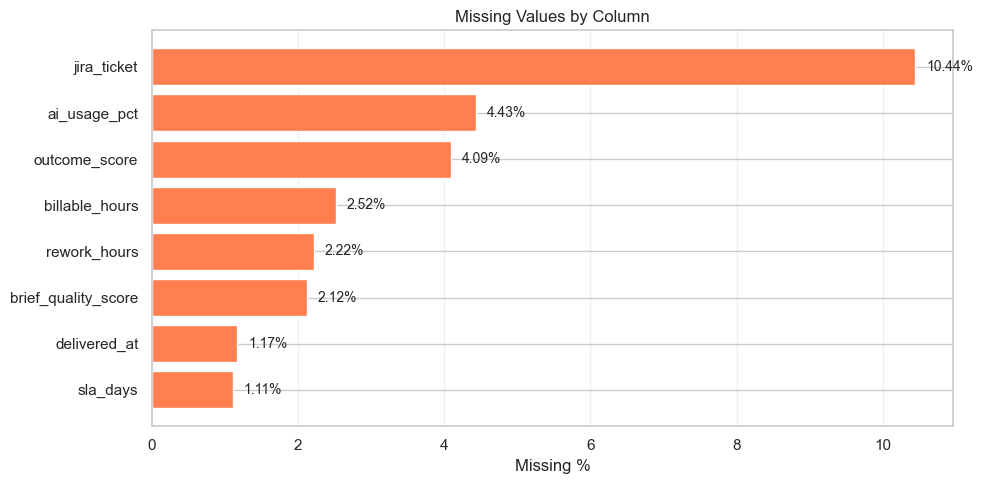

In [224]:
# Filter columns with at least one missing value
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'null_count': missing,
    'null_pct': missing_pct
})

print(f"Columns with missing values: {len(missing_df)} / {df.shape[1]}\n")
print(missing_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_df.index[::-1], missing_df['null_pct'][::-1], color='coral', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
ax.grid(axis='x', alpha=0.3)

for i, (val, name) in enumerate(zip(missing_df['null_pct'][::-1], missing_df.index[::-1])):
    ax.text(val + 0.15, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

8 out of 34 columns have missing values. The most affected is `jira_ticket` (339, 10.44%), which is a metadata field and not critical for modeling. Among the analytically relevant variables, `ai_usage_pct` (144, 4.43%) and `outcome_score` (133, 4.09%) have the highest missingness, followed by `billable_hours` (82), `rework_hours` (72), and `brief_quality_score` (69), all in the 2–2.5% range. The two time-related columns `delivered_at` (38) and `sla_days` (36) have minimal gaps just above 1%. No column exceeds 11%, so the overall data completeness is high. The specific patterns behind these missing values — whether random or structurally driven — will be investigated during the cleaning phase.

### 3.3 — Duplicate Check

The audit showed 3,248 rows but only 3,200 unique `task_id` values. We investigate the nature of these duplicates to decide how to handle them in the cleaning phase.

In [225]:
# Count duplicates
n_dupes = df['task_id'].duplicated().sum()
n_unique_duped = df[df['task_id'].duplicated(keep=False)]['task_id'].nunique()
print(f"Duplicated rows: {n_dupes}")
print(f"Unique task_ids involved: {n_unique_duped}")
print(f"Total rows involved: {n_dupes + n_unique_duped}")

# Inspect a sample of duplicate pairs — compare key fields
duped_ids = df[df['task_id'].duplicated(keep=False)]['task_id'].unique()
compare_cols = ['task_id', 'client', 'hours_spent', 'revenue', 'cost', 'profit',
                'ai_usage_pct', 'created_by', 'updated_at', 'task_status', 'content_version']

print(f"\n--- Sample duplicate pairs (first 5) ---\n")
for tid in duped_ids[:5]:
    pair = df[df['task_id'] == tid][compare_cols]
    print(pair.to_string(index=False))
    print()

Duplicated rows: 48
Unique task_ids involved: 48
Total rows involved: 96

--- Sample duplicate pairs (first 5) ---

task_id   client  hours_spent  revenue   cost  profit  ai_usage_pct created_by updated_at task_status content_version
 T00010 Client_F        11.57   743.55 756.78  -13.23          0.38   user_064 2025-09-12   delivered           final
 T00010 Client_J        11.57   743.55 756.78  -13.23          0.38   user_078 2025-09-11 in_progress              v3

task_id   client  hours_spent  revenue   cost  profit  ai_usage_pct created_by updated_at task_status content_version
 T00139 Client_H        12.39  1130.56 919.75  210.81           NaN   user_011 2026-03-04 in_progress              v1
 T00139 Client_H        12.39  1130.56 919.75  210.81          0.47   user_059 2026-03-05   delivered              v4

task_id   client  hours_spent  revenue    cost  profit  ai_usage_pct created_by updated_at task_status content_version
 T00170 Client_H        13.34   795.16 1048.97 -253.81 

There are 48 duplicate `task_id` values, involving 96 total rows (48 pairs). Within each pair, the core business data is identical — `hours_spent`, `revenue`, `cost`, `profit`, and `ai_usage_pct` all match — while metadata fields differ: `created_by`, `updated_at`, `task_status`, and `content_version`. In one case (T00010) even `client` differs between the two rows (Client_F vs Client_J), suggesting a data entry error in the duplicate record.

This pattern is consistent with system-level duplicates: the same task recorded twice with different metadata states, not genuinely distinct tasks. In the cleaning phase, for each pair we will keep the row with the most recent `updated_at`, as it represents the latest known state of the task.

### 3.4 — Categorical Variables

We inspect the frequency distribution of the main categorical variables to identify naming inconsistencies, unexpected values, and class imbalances.

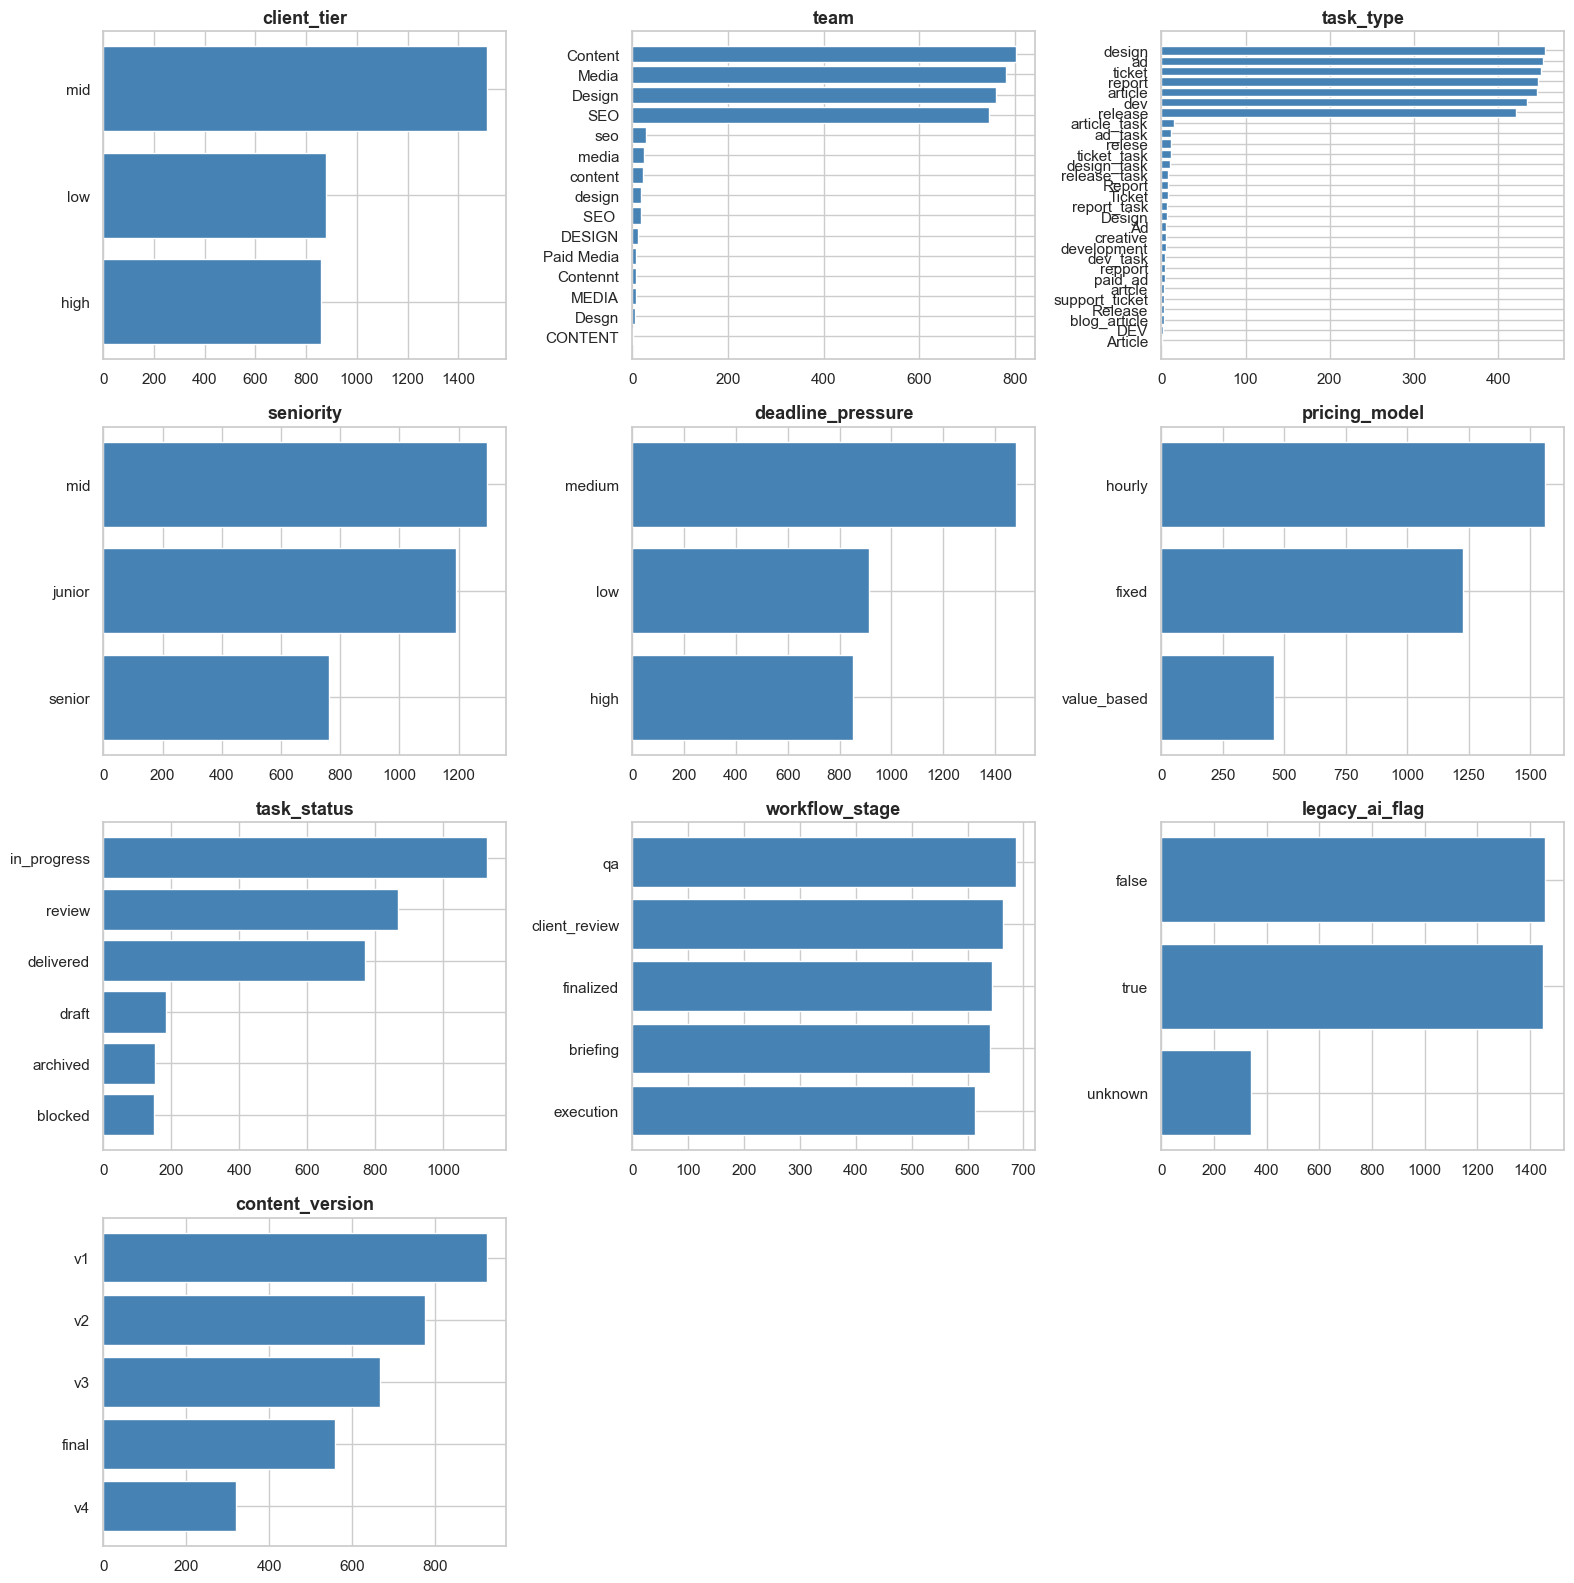

In [226]:
cat_cols = ['client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure',
            'pricing_model', 'task_status', 'workflow_stage', 'legacy_ai_flag', 'content_version']

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    counts = df[col].value_counts()
    ax.barh(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.invert_yaxis()

for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

The variables `client_tier`, `seniority`, `deadline_pressure`, and `workflow_stage` are clean and well-distributed, with no unexpected values. `pricing_model` shows a clear hierarchy: `hourly` dominates (~48%), followed by `fixed` (~38%) and `value_based` (~14%). `task_status` is skewed toward `in_progress` and `review`, with smaller groups for `draft`, `archived`, and `blocked`. `legacy_ai_flag` is split roughly 50/50 between `true` and `false`, with a third category `unknown` (~10%) that will need clarification. `content_version` ranges from `v1` to `v4` plus `final`, with a decreasing trend from v1 to v4.

The two most problematic columns are `team` and `task_type`. `team` has 15 unique values representing just 4 actual teams (Content, Design, Media, SEO), with case variations (content, CONTENT), typos (Contennt, Desgn), and a subcategory (Paid Media). `task_type` has 29 unique values that map to approximately 7 core categories, with similar issues: case inconsistencies, typos (relese, repport, artcle), suffixed variants (_task), and synonyms (creative, development, blog_post). Both columns require normalization in the cleaning phase.

### 3.5 — Numerical Variables

We examine the distribution of all continuous and discrete numerical variables through descriptive statistics and histograms. This helps identify skewness, unusual ranges, and potential data quality issues before cleaning.

In [227]:
# Descriptive statistics
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical variables: {len(numerical_cols)}\n")
df[numerical_cols].describe().round(2).T

Numerical variables: 15



,count,mean,std,min,25%,50%,75%,max
task_complexity_score,3248.0,2.87,1.20,1.00,2.00,3.00,4.00,5.00
brief_quality_score,3179.0,3.18,1.21,1.00,2.00,3.00,4.00,5.00
scope_change_flag,3248.0,0.14,0.35,0.00,0.00,0.00,0.00,1.00
sla_days,3212.0,5.01,2.52,2.00,3.00,5.00,7.00,10.00
sla_breach,3248.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
hours_spent,3248.0,13.06,11.56,0.02,7.91,11.11,15.34,263.60
billable_hours,3166.0,8.43,4.78,-1.90,5.08,7.54,10.69,47.02
ai_usage_pct,3104.0,0.36,0.20,0.00,0.20,0.34,0.50,0.93
revisions,3248.0,3.01,1.80,0.00,2.00,3.00,4.00,11.00
errors,3248.0,1.01,1.04,0.00,0.00,1.00,2.00,7.00


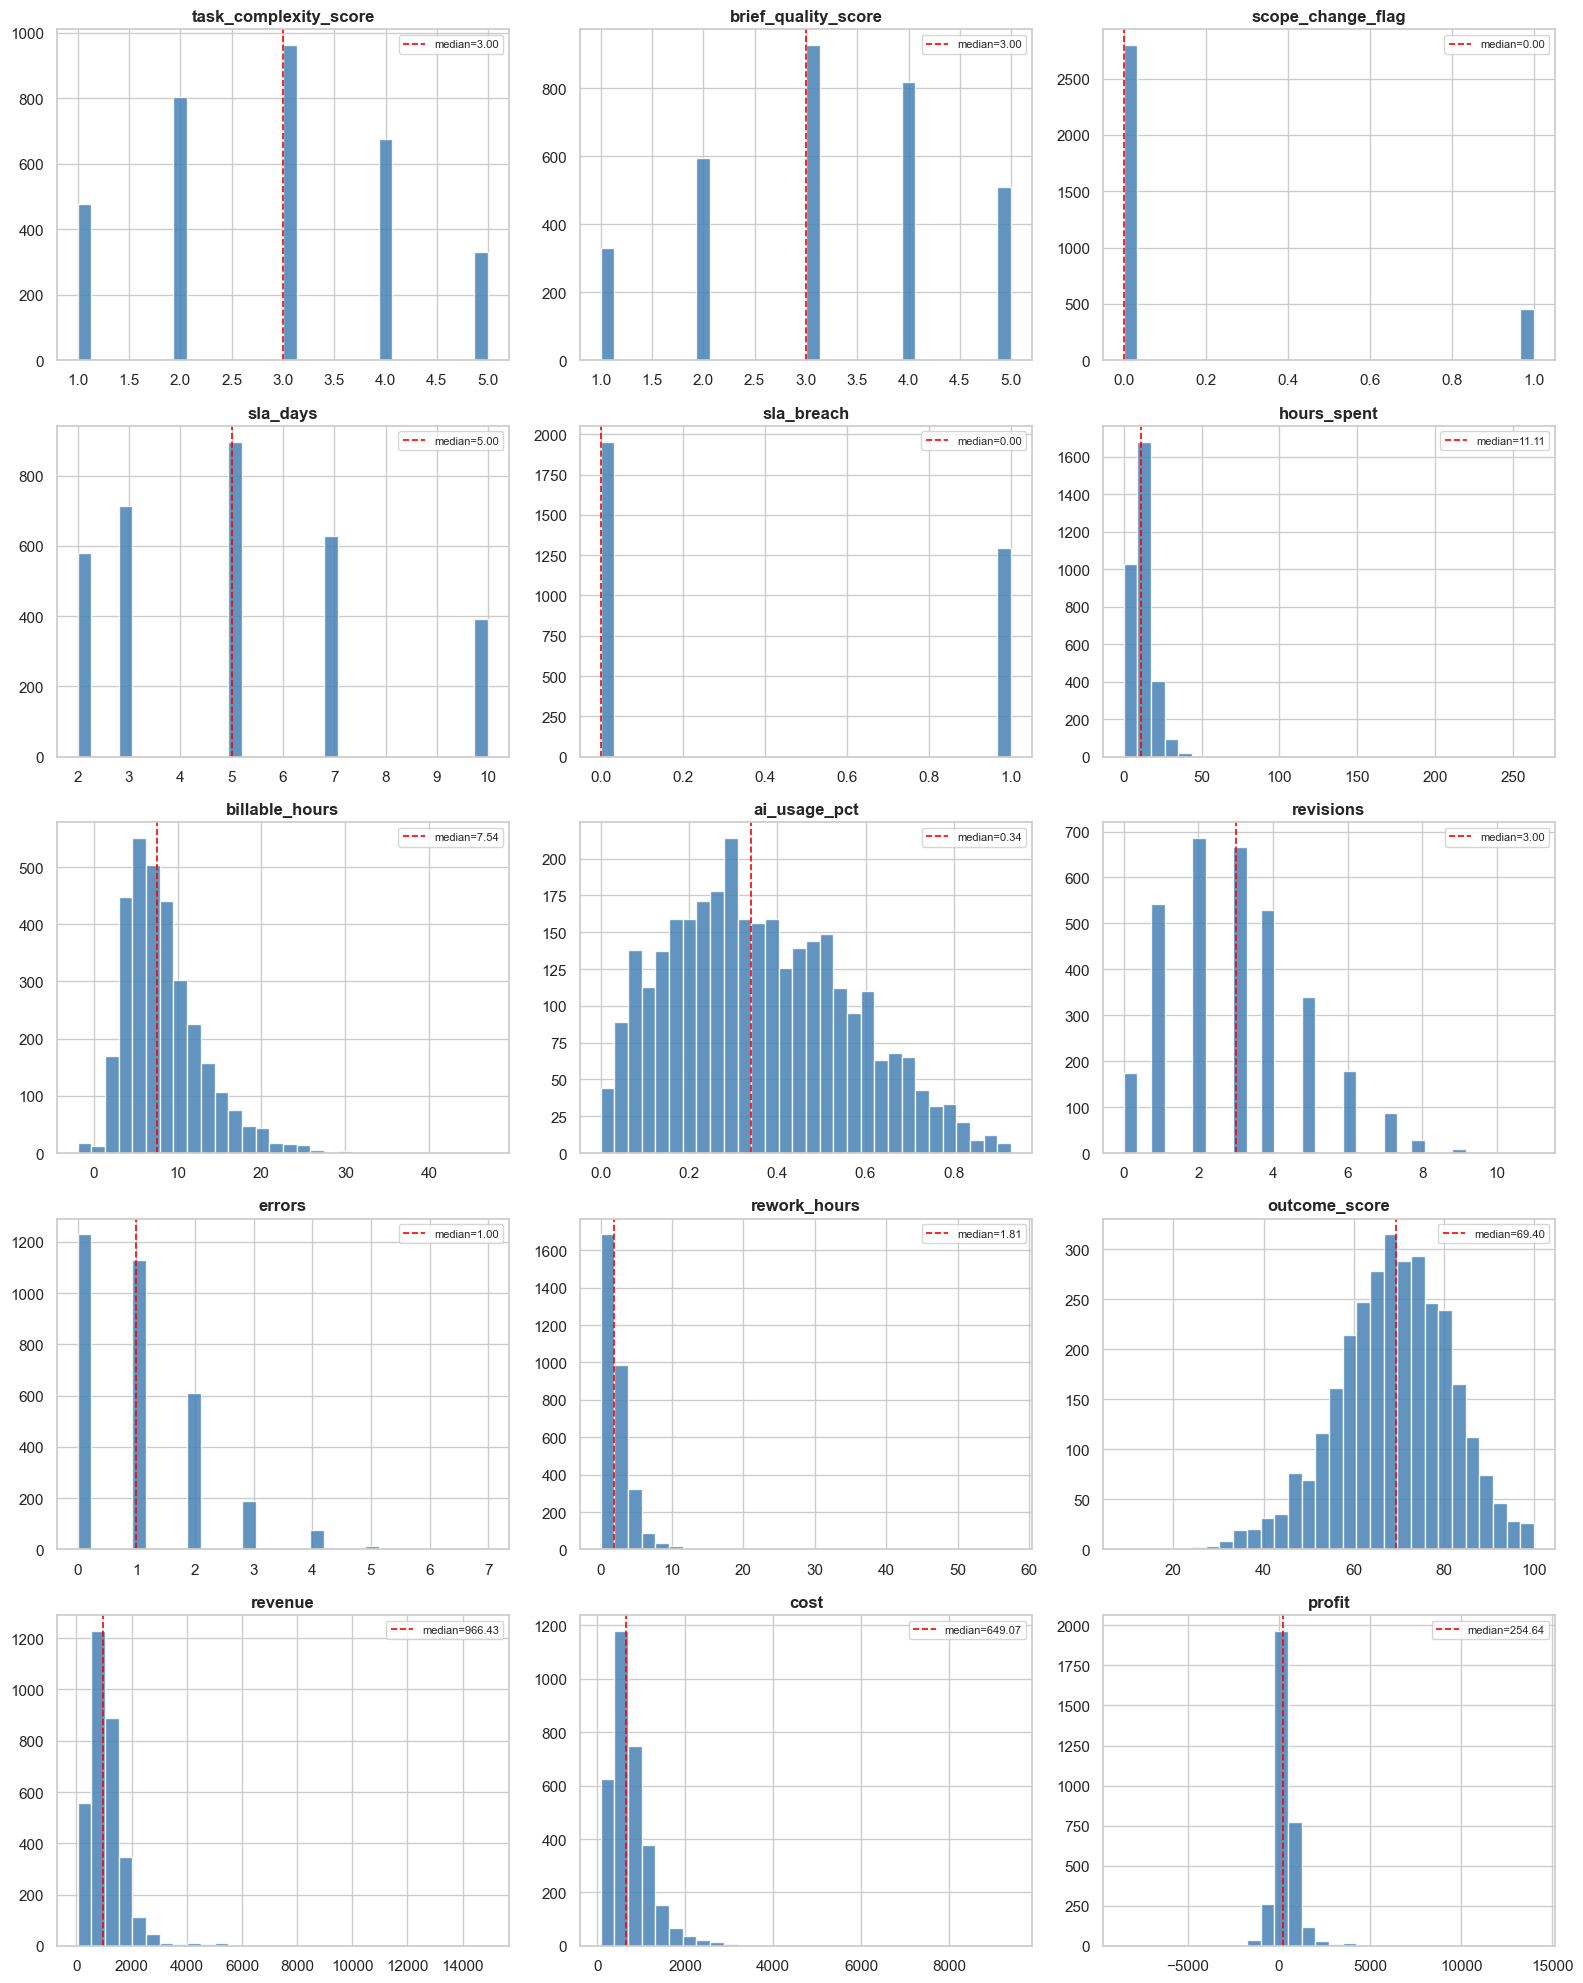

In [228]:
# Histograms
n_cols_plot = 3
n_rows_plot = (len(numerical_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    data = df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'median={data.median():.2f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

The 15 numerical variables fall into three groups by distribution shape.

**Well-behaved variables:** `task_complexity_score` and `brief_quality_score` are discrete scales (1–5) with roughly uniform distributions centered on 3. `ai_usage_pct` is approximately normal (mean 0.36, median 0.34), ranging from 0 to 0.93. `outcome_score` is also near-normal (mean 68.9, median 69.4) on a 0–100 scale. `sla_days` takes only 5 discrete values (2, 3, 5, 7, 10).

**Right-skewed variables:** `hours_spent` (median 11.1h, max 263.6h), `billable_hours` (median 7.5h, max 47h), `rework_hours` (median 1.8h, max 57.5h), `revenue` (median €966, max €14,927), `cost` (median €649, max €9,410), and `profit` (median €255, max €14,007) are all heavily right-skewed with long upper tails. `revisions` and `errors` follow a similar pattern on a smaller scale.

**Data quality flags:** `billable_hours` has a negative minimum (-1.90), which is logically impossible. `hours_spent` reaches 263.6h (over 6 full work weeks on a single task), and `profit` ranges from -€8,511 to +€14,007. `scope_change_flag` and `sla_breach` are binary (0/1) and not meaningful as continuous distributions.

### 3.6 — Outlier Detection

We use boxplots and the IQR method to identify outliers across numerical variables. We exclude binary columns (`scope_change_flag`, `sla_breach`) since boxplots are not informative for them.

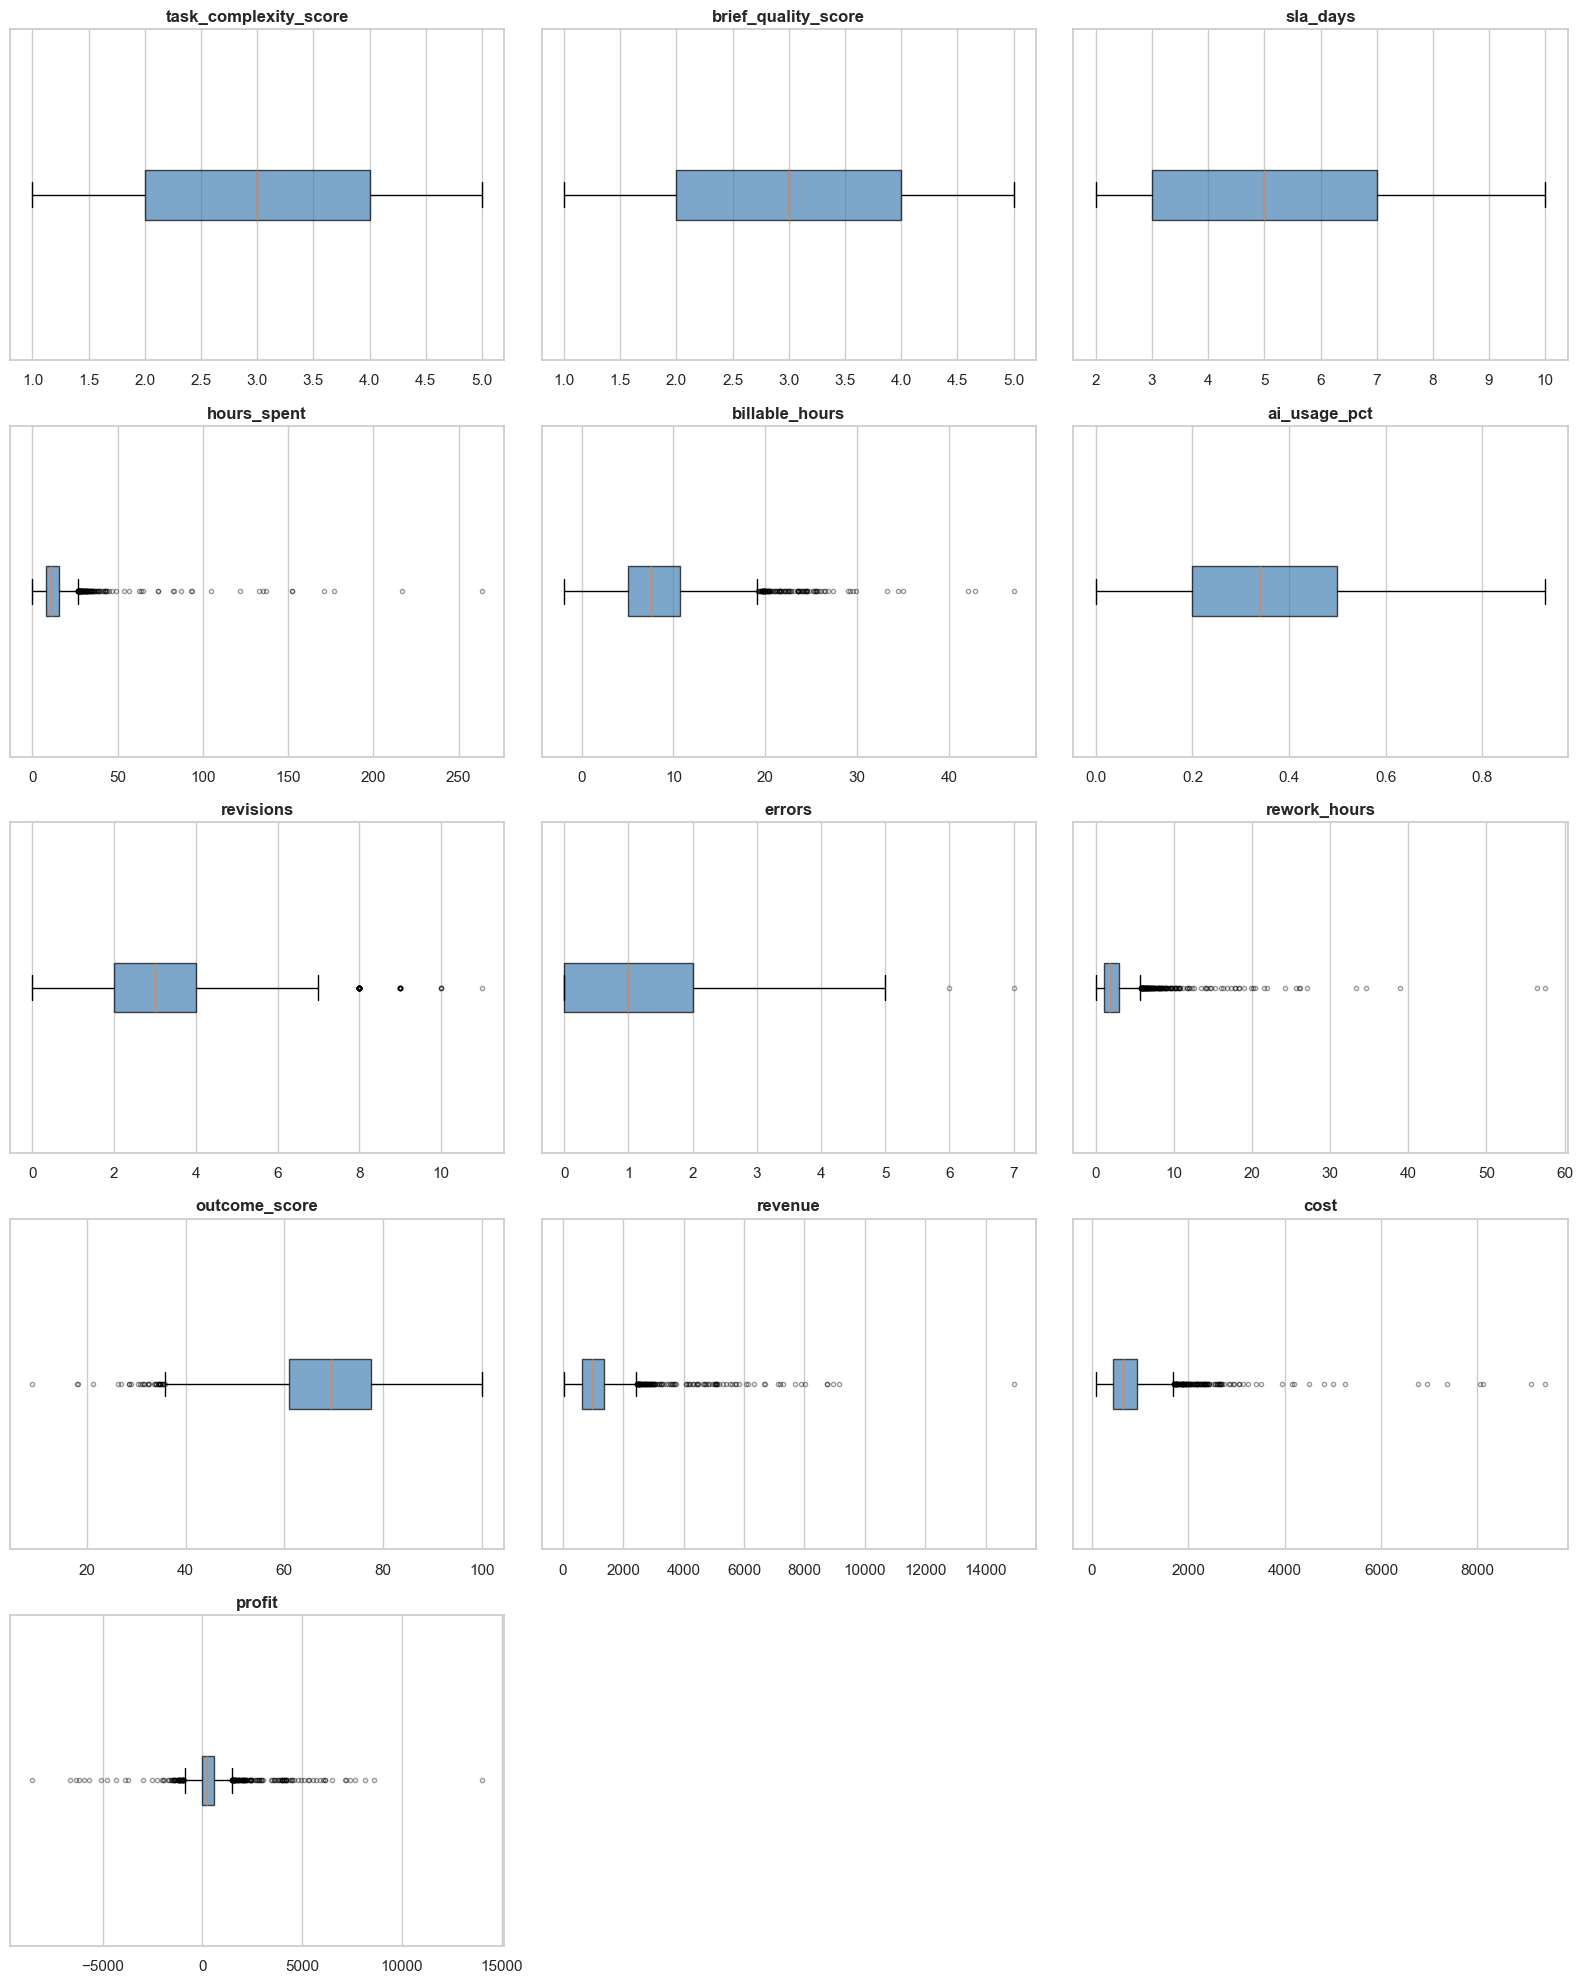

In [229]:
# Exclude binary variables
continuous_cols = [c for c in numerical_cols if c not in ['scope_change_flag', 'sla_breach']]

n_cols_plot = 3
n_rows_plot = (len(continuous_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, vert=False,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_yticks([])

for idx in range(len(continuous_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [230]:
# IQR outlier count per variable
print("OUTLIER DETECTION — IQR METHOD (1.5 × IQR)\n")

outlier_rows = []
for col in continuous_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_rows.append({
        'variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outliers': n_out,
        'outliers_pct': round(n_out / len(data) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_rows)
print(outlier_df.to_string(index=False))

OUTLIER DETECTION — IQR METHOD (1.5 × IQR)

             variable     Q1      Q3    IQR  lower_bound  upper_bound  outliers  outliers_pct
task_complexity_score   2.00    4.00   2.00        -1.00         7.00         0          0.00
  brief_quality_score   2.00    4.00   2.00        -1.00         7.00         0          0.00
             sla_days   3.00    7.00   4.00        -3.00        13.00         0          0.00
          hours_spent   7.91   15.34   7.43        -3.24        26.50       136          4.19
       billable_hours   5.08   10.69   5.61        -3.33        19.10       109          3.44
         ai_usage_pct   0.20    0.50   0.30        -0.25         0.95         0          0.00
            revisions   2.00    4.00   2.00        -1.00         7.00        41          1.26
               errors   0.00    2.00   2.00        -3.00         5.00         2          0.06
         rework_hours   1.11    2.95   1.84        -1.65         5.71       182          5.73
        outcome_

The score-based variables (`task_complexity_score`, `brief_quality_score`, `sla_days`, `ai_usage_pct`) are outlier-free, confirming their structural integrity.

The time and financial variables concentrate most of the issues. `hours_spent` has 136 outliers (4.19%) above 26.5h, with extreme values reaching 263h. `rework_hours` has 182 outliers (5.73%) above 5.7h, with a max of 57.5h. `billable_hours` has 109 outliers (3.44%) and a negative lower bound in the data (min = -1.90), confirming the data quality issue identified earlier. Among the financial variables, `profit` is the most affected with 190 outliers (5.85%) on both tails — the negative lower bound (-€892) captures loss-making tasks, while the upper bound (€1,480) flags high-profit tasks up to €14,007. `revenue` (133 outliers, 4.09%) and `cost` (146 outliers, 4.50%) show similar right-tail concentration.

`revisions` has 41 outliers (1.26%) at the upper end (>7), and `errors` is nearly clean with only 2 outliers. `outcome_score` has 33 low-end outliers (1.06%) below 35.8, representing unusually poor task outcomes.

### 3.7 — Preliminary EDA Summary

The exploratory analysis on raw data identified the following issues to address in the cleaning phase:

**Duplicates:** 48 duplicate `task_id` pairs (96 rows) with identical business data but diverging metadata. Strategy: keep the most recent row per `task_id`.

**Dirty categoricals:** `team` has 15 variants for 4 actual teams (case errors, typos, subcategories). `task_type` has 29 variants for ~7 core categories (typos, suffixes, synonyms). Both require normalization through explicit mapping dictionaries.

**Missing values:** 8 columns affected. Most critical for the analysis are `ai_usage_pct` (144, 4.43%) and `outcome_score` (133, 4.09%). `billable_hours` (82), `rework_hours` (72), and `brief_quality_score` (69) are in the 2–2.5% range. `delivered_at` (38) and `sla_days` (36) have minimal gaps. `jira_ticket` (339, 10.44%) is metadata and not essential for modeling.

**Outliers and data quality:** The time variables (`hours_spent`, `billable_hours`, `rework_hours`) and financial variables (`revenue`, `cost`, `profit`) show heavy right-skewness with significant outlier concentrations (4–6%). Specific anomalies include negative `billable_hours` (min = -1.90) and extreme `hours_spent` values (max = 263.6h). `profit` ranges from -€8,511 to +€14,007.

**Date columns:** `created_at`, `delivered_at`, and `updated_at` are stored as strings and need datetime parsing.

---

## 4. Data Cleaning

We clean each variable individually, documenting every decision. The order follows the column sequence in the dataset. For each variable we inspect, decide, act, and validate.

### 4.1 — task_id

Unique identifier for each task. The EDA found 48 duplicate pairs (96 rows) with identical business data but different metadata. For each pair, we keep the row with the most recent `updated_at`.

In [231]:
print(f"Null values: {df['task_id'].isnull().sum()}")
print(f"Unique values: {df['task_id'].nunique()}")
print(f"Duplicates: {df['task_id'].duplicated().sum()}")
duplicated_ids = df[df['task_id'].duplicated(keep=False)].sort_values('task_id')
print(f"Total rows involved in duplicates: {len(duplicated_ids)}")
print(f"Unique duplicated IDs: {duplicated_ids['task_id'].nunique()}")


Null values: 0
Unique values: 3200
Duplicates: 48
Total rows involved in duplicates: 96
Unique duplicated IDs: 48


In [232]:
duplicated_ids_list = df[df['task_id'].duplicated(keep=False)]['task_id'].unique()
comparison_cols = ['task_id', 'client', 'created_by', 'updated_at', 'task_status', 
                   'jira_ticket', 'legacy_ai_flag', 'content_version']

for tid in duplicated_ids_list[:49]:  # first 10 pairs
    pair = df[df['task_id'] == tid][comparison_cols]
    print(pair.to_string())
    print("-" * 80)
    

     task_id    client created_by  updated_at  task_status jira_ticket legacy_ai_flag content_version
10    T00010  Client_F   user_064  2025-09-12    delivered  JIRA-82158          false           final
3233  T00010  Client_J   user_078  2025-09-11  in_progress  JIRA-63281        unknown              v3
--------------------------------------------------------------------------------
     task_id    client created_by  updated_at  task_status jira_ticket legacy_ai_flag content_version
139   T00139  Client_H   user_011  2026-03-04  in_progress  JIRA-21055           true              v1
3202  T00139  Client_H   user_059  2026-03-05    delivered  JIRA-92895          false              v4
--------------------------------------------------------------------------------
     task_id    client created_by  updated_at  task_status jira_ticket legacy_ai_flag content_version
170   T00170  Client_H   user_003  2025-09-10  in_progress  JIRA-59955           true              v3
3237  T00170  Client_H

All 48 duplicate pairs share identical core data (hours, financials, scores, AI usage) but differ in metadata fields (`client`, `created_by`, `updated_at`, `task_status`, `jira_ticket`, `legacy_ai_flag`, `content_version`). This is consistent with system-level duplicates, the same task recorded twice with different metadata states.
Some pairs also differ in `client` (e.g. T00010: Client_F vs Client_J), suggesting possible data entry errors in the duplicate row.
For each pair, we keep the row with the **most recent `updated_at`**, as it represents the latest known state of the task. This drops 48 rows (1.5% of data) with no loss of analytical variables.

In [233]:
rows_before = len(df)

# Sort by updated_at descending so the most recent comes first
df = df.sort_values('updated_at', ascending=False)

# Keep first occurrence (most recent) for each task_id
df = df.drop_duplicates(subset='task_id', keep='first')

# Restore original order
df = df.sort_values('task_id').reset_index(drop=True)

rows_after = len(df)
print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Dropped:     {rows_before - rows_after} duplicate rows")
print(f"Unique task_ids: {df['task_id'].nunique()} (expected: {rows_after})")

Rows before: 3248
Rows after:  3200
Dropped:     48 duplicate rows
Unique task_ids: 3200 (expected: 3200)


### 4.2 — client

`client` identifies which client the task belongs to. We check for nulls, unexpected values, and distribution.

In [234]:
print(f"Null values: {df['client'].isnull().sum()}")
print(f"Unique values: {df['client'].nunique()}")
print(f"\nDistribution:")
print(df['client'].value_counts())

Null values: 0
Unique values: 28

Distribution:
client
Client_G    410
Client_B    392
Client_E    389
Client_H    385
Client_D    381
Client_C    371
Client_A    358
Client_F    356
Client_L     13
Client_Z     13
Client_[     11
Client_K     11
Client_S     10
Client_U     10
Client_T     10
Client_R      9
Client_\      9
Client_Q      8
Client_N      7
Client_Y      7
Client_M      7
Client_P      6
Client_W      5
Client_J      5
Client_O      5
Client_X      5
Client_I      4
Client_V      3
Name: count, dtype: int64


The dataset presents 28 unique clients, but a clear split:
- **8 main clients** (A through H): 356-410 records each, totaling ~97% of the dataset.
- **20 minor clients** (I through Z plus `Client_[` and `Client_\`): 3-13 records each.



### 4.3 — project_id

`project_id` links tasks to projects.

In [235]:
print(f"Null values: {df['project_id'].isnull().sum()}")
print(f"Unique values: {df['project_id'].nunique()}")
print(f"Format sample: {df['project_id'].head(5).tolist()}")

Null values: 0
Unique values: 64
Format sample: ['P038', 'P028', 'P009', 'P023', 'P014']


`project_id` is clean. 64 unique projects, all following the `P0XX` format, no nulls.


### 4.4 — client_tier

Expected values: low, mid, high.


In [236]:
print(f"Null values: {df['client_tier'].isnull().sum()}")
print(f"Unique values: {df['client_tier'].nunique()}")
print(f"\nDistribution:")
print(df['client_tier'].value_counts())

Null values: 0
Unique values: 3

Distribution:
client_tier
mid     1491
low      867
high     842
Name: count, dtype: int64


`client_tier` is clean. 3 values as expected, no nulls. Distribution skews toward `mid`, with `low` and `high` roughly balanced. No cleaning needed.


### 4.5 — team

`team` identifies the operational team responsible for the task.


In [237]:
df['team'].value_counts()

team
Content       796
Media         768
Design        754
SEO           733
seo            27
media          24
content        22
design         19
SEO            18
DESIGN         12
Paid Media      7
Contennt        7
MEDIA           6
Desgn           5
CONTENT         2
Name: count, dtype: int64

The `team` variable contains **15 unique values** representing 4 actual teams. However, there are some issues with the words. Indeed we have some typos and mispelled words that create inconsistencies. Furthermore, we have some "subcategories" like `Paid Media` that could be labeled directly under `Media`. So we decided to merge them since a small category label as such would make the analysis irrelevant.


In [238]:
team_mapping = {
    'Content': 'Content',
    'content': 'Content',
    'CONTENT': 'Content',
    'Contennt': 'Content',
    
    'Design': 'Design',
    'design': 'Design',
    'Desgn' : 'Design',
    'DESIGN': 'Design',
    
    'Media': 'Media',
    'media': 'Media',
    'MEDIA': 'Media',
    'Paid Media': 'Media',  
    
    'SEO': 'SEO',
    'seo': 'SEO',
    'SEO ' : 'SEO'
}

df['team'] = df['team'].map(team_mapping)

The team mapping process was highly successful, reducing the initial 15 unique values, which contained various typos, case variations, and inconsistencies, into 4 canonical categories: Content, Design, Media, and SEO. All 3,248 records were suiccessfully processed, resulting in a remarkably balanced final distribution where each team accounts for approximately 25% of the workload, ranging from 794 tasks for SEO to 835 for Content. This cleanup is critical for the upcoming analysis as it enables reliable team-level segmentation and ensures that all aggregations, such as mean profit or AI usage per team, are statistically accurate. Furthermore, this balanced distribution provides a solid foundation for modeling "team" as a categorical feature, ensuring a sufficient sample size for every group and preventing any single department from biasing the results.


### 4.6 — task_type

`task_type` describes the nature of the task. 

In [239]:
df['task_type'].value_counts()

task_type
design            450
ticket            447
ad                446
report            441
article           439
dev               426
release           416
article_task       14
relese             11
ticket_task        11
design_task        10
ad_task            10
Ticket              8
Report              7
release_task        7
report_task         7
Design              7
Ad                  6
development         5
creative            5
dev_task            4
repport             4
paid_ad             4
artcle              3
support_ticket      3
Release             3
blog_article        3
DEV                 2
Article             1
Name: count, dtype: int64

The mapping process successfully consolidated 29 distinct task variants into seven canonical categories: design, ad, ticket, report, article, dev, and release. This normalization addressed several data quality issues, including inconsistent casing, common typos such as "relese" and "repport," and the redundant use of the "_task" suffix across multiple categories. Additionally, the process resolved synonym conflicts by merging specific terms like "creative" into design, "development" into dev, and "support_ticket" into ticket. By standardizing these inputs, the dataset now accurately reflects the core activities of the workflow, ensuring that future aggregations and modeling efforts are not fragmented by minor naming inconsistencies.

In [240]:
df['task_type'] = df['task_type'].str.strip().str.lower()

task_type_mapping = {

    'design': 'design',
    'design_task': 'design',
    'creative': 'design',

    'ad': 'ad',
    'ad_task': 'ad',
    'paid_ad': 'ad',
   
    'ticket': 'ticket',
    'ticket_task': 'ticket',
    'support_ticket': 'ticket',
    
    'report': 'report',
    'report_task': 'report',
    'repport': 'report',
   
    'article': 'article',
    'article_task': 'article',
    'artcle': 'article',
    'blog_article': 'article',
  
    'dev': 'dev',
    'dev_task': 'dev',
    'development': 'dev',

    'release': 'release',
    'release_task': 'release',
    'relese': 'release',
}

df['task_type'] = df['task_type'].map(task_type_mapping)

df['task_type'].value_counts()

task_type
design     472
ticket     469
ad         466
article    460
report     459
release    437
dev        437
Name: count, dtype: int64

All 3,200 records successfully mapped to 7 canonical task types with 0 unmapped values. The distribution is well balanced (~443-478 per category), confirming no data was lost in the mapping. 

### 4.7 — seniority

`seniority` indicates the experience level of the person who executed the task. Expected values: junior, mid, senior.

In [241]:
print(f"Null values: {df['seniority'].isnull().sum()}")
print(f"Unique values: {df['seniority'].nunique()}")
print(f"\nDistribution:")
print(df['seniority'].value_counts())

Null values: 0
Unique values: 3

Distribution:
seniority
mid       1278
junior    1169
senior     753
Name: count, dtype: int64


`seniority` is clean. 3 values, no nulls. Distribution: `mid` (40%), `junior` (37%), `senior` (23%). Note the lower proportion of seniors — this is realistic for a digital agency. No cleaning needed.


### 4.8 — task_complexity_score

`task_complexity_score` integer score representing task complexity.

In [242]:
print(f"Null values: {df['task_complexity_score'].isnull().sum()}")
print(f"\nValue counts:")
print(df['task_complexity_score'].value_counts().sort_index())

Null values: 0

Value counts:
task_complexity_score
1    469
2    796
3    946
4    664
5    325
Name: count, dtype: int64


 `task_complexity_score` is clean. Integer scale 1-5, no nulls. Distribution is roughly normal, centered on 3 (median), with fewer tasks at the extremes. No cleaning needed.


### 4.9 — brief_quality_score

`brief_quality_score` is a discrete score (1–5) rating the quality of the initial brief provided for the task. 

In [243]:
print(f"Null values: {df['brief_quality_score'].isnull().sum()}")
print(f"Null %: {df['brief_quality_score'].isnull().mean()*100:.2f}%")
print(f"\nValue counts (non-null):")
print(df['brief_quality_score'].value_counts().sort_index())
print(f"\nDescriptive stats:")
print(df['brief_quality_score'].describe())

# Check if missingness is random across key segments
print(f"\n--- Missing % by team ---")
print((df.groupby('team')['brief_quality_score'].apply(lambda x: x.isnull().mean()*100)).round(2).to_string())

print(f"\n--- Missing % by seniority ---")
print((df.groupby('seniority')['brief_quality_score'].apply(lambda x: x.isnull().mean()*100)).round(2).to_string())

Null values: 68
Null %: 2.12%

Value counts (non-null):
brief_quality_score
1.0    323
2.0    590
3.0    910
4.0    800
5.0    509
Name: count, dtype: int64

Descriptive stats:
count    3132.000000
mean        3.185824
std         1.213394
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: brief_quality_score, dtype: float64

--- Missing % by team ---
team
Content    2.42
Design     2.91
Media      2.36
SEO        0.77

--- Missing % by seniority ---
seniority
junior    2.40
mid       1.72
senior    2.39


68 missing values imputed using the group-based median on `team × seniority × task_type`. This approach leverages the intuition that brief quality varies by team, experience level, and task type, producing more context-aware imputations than a global median. A global median fallback was set for any group with all-NaN values (none triggered). Values were rounded to preserve the original 1–5 discrete scale. All 3,200 rows now have a valid `brief_quality_score`.

In [244]:
# Group-based median imputation on team × seniority × task_type
n_before = df['brief_quality_score'].isnull().sum()

# Compute group medians
group_medians = df.groupby(['team', 'seniority', 'task_type'])['brief_quality_score'].transform('median')

# Fallback: global median for any group with all NaN (unlikely but safe)
global_median = df['brief_quality_score'].median()

# Fill: group median first, then global median as safety net
df['brief_quality_score'] = df['brief_quality_score'].fillna(group_medians).fillna(global_median)

# Round to integer scale (1-5) since the original variable is discrete
df['brief_quality_score'] = df['brief_quality_score'].round().astype(float)

print(f"Imputed {n_before} missing values using group-based median (team × seniority × task_type)")
print(f"Fallback global median: {global_median}")
print(f"Remaining nulls: {df['brief_quality_score'].isnull().sum()}")
print(f"\nPost-imputation distribution:")
print(df['brief_quality_score'].value_counts().sort_index())

# Check: imputed value distribution
print(f"\nMean after imputation: {df['brief_quality_score'].mean():.3f} (before: 3.183)")

Imputed 68 missing values using group-based median (team × seniority × task_type)
Fallback global median: 3.0
Remaining nulls: 0

Post-imputation distribution:
brief_quality_score
1.0    323
2.0    590
3.0    962
4.0    816
5.0    509
Name: count, dtype: int64

Mean after imputation: 3.187 (before: 3.183)


### 4.10 — deadline_pressure

`deadline_pressure` indicates the time pressure level on the task. Expected values: low, medium, high.

In [245]:
print(f"Null values: {df['deadline_pressure'].isnull().sum()}")
print(f"Unique values: {df['deadline_pressure'].nunique()}")
print(f"\nDistribution:")
print(df['deadline_pressure'].value_counts())

Null values: 0
Unique values: 3

Distribution:
deadline_pressure
medium    1463
low        896
high       841
Name: count, dtype: int64


`deadline_pressure` is clean. 3 values, no nulls. Distribution skews toward `medium` (46%). No cleaning needed.


### 4.11 — scope_change_flag

Binary flag (0/1) indicating whether the task scope changed during execution. 

In [246]:
print(f"Null values: {df['scope_change_flag'].isnull().sum()}")
print(f"\nValue counts:")
print(df['scope_change_flag'].value_counts())

Null values: 0

Value counts:
scope_change_flag
0    2757
1     443
Name: count, dtype: int64


`scope_change_flag` is clean. Binary (0/1), no nulls. 14% of tasks had a scope change. No cleaning needed.


### 4.12 — pricing_model

Billing model used for the task.

In [247]:
print(f"Null values: {df['pricing_model'].isnull().sum()}")
print(f"Unique values: {df['pricing_model'].nunique()}")
print(f"\nDistribution:")
print(df['pricing_model'].value_counts())

Null values: 0
Unique values: 3

Distribution:
pricing_model
hourly         1542
fixed          1204
value_based     454
Name: count, dtype: int64


`pricing_model` is clean. 3 values, no nulls. `hourly` is the most common (48%), followed by `fixed` (38%) and `value_based` (14%). No cleaning needed.


### 4.13 - created_at

Date when the task was created. We need to verify the format, parse it as datetime, and check for any invalid or out-of-range dates.

In [248]:
print(f"Null values: {df['created_at'].isnull().sum()}")
print(f"Dtype: {df['created_at'].dtype}")
print(f"\nSample values: {df['created_at'].head(5).tolist()}")

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print(f"\nAfter parsing:")
print(f"Dtype: {df['created_at'].dtype}")
print(f"Failed to parse (NaT): {df['created_at'].isnull().sum()}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

Null values: 0
Dtype: object

Sample values: ['2025-11-20', '2026-01-24', '2025-09-16', '2025-11-06', '2026-05-02']

After parsing:
Dtype: datetime64[ns]
Failed to parse (NaT): 0
Date range: 2025-07-01 00:00:00 to 2026-05-26 00:00:00


`created_at` successfully parsed to datetime. No nulls, no invalid dates. Date range: July 2025 to May 2026 (~11 months of operations). No cleaning needed.


### 4.14 — delivered_at

Date when the task should be delivered. 

In [249]:
print(f"Null values: {df['delivered_at'].isnull().sum()}")
print(f"Null %: {df['delivered_at'].isnull().mean()*100:.2f}%")
print(f"Dtype: {df['delivered_at'].dtype}")

df['delivered_at'] = pd.to_datetime(df['delivered_at'], errors='coerce')

print(f"\nAfter parsing:")
print(f"Failed to parse (NaT): {df['delivered_at'].isnull().sum()}")
print(f"Date range (non-null): {df['delivered_at'].min()} to {df['delivered_at'].max()}")

# Check: are null delivered_at related to task_status?
print(f"\nTask status for rows with missing delivered_at:")
print(df[df['delivered_at'].isnull()]['task_status'].value_counts())

Null values: 38
Null %: 1.19%
Dtype: object

After parsing:
Failed to parse (NaT): 38
Date range (non-null): 2025-07-03 00:00:00 to 2026-06-02 00:00:00

Task status for rows with missing delivered_at:
task_status
delivered      13
in_progress    12
review          7
archived        4
blocked         1
draft           1
Name: count, dtype: int64


In [250]:
missing_mask = df['delivered_at'].isnull()

# Check overlap with sla_days missing
sla_also_missing = df.loc[missing_mask, 'sla_days'].isnull().sum()
print(f"Missing delivered_at: {missing_mask.sum()}")
print(f"Of which also missing sla_days: {sla_also_missing}")
print(f"Estimable with created_at + sla_days: {missing_mask.sum() - sla_also_missing}")

# Estimate: created_at + sla_days
df.loc[missing_mask & df['sla_days'].notnull(), 'delivered_at'] = (
    df.loc[missing_mask & df['sla_days'].notnull(), 'created_at'] +
    pd.to_timedelta(df.loc[missing_mask & df['sla_days'].notnull(), 'sla_days'], unit='D')
)

# Fallback for remaining: use updated_at as proxy
still_missing = df['delivered_at'].isnull().sum()
print(f"\nAfter sla_days estimation — still missing: {still_missing}")

if still_missing > 0:
    df.loc[df['delivered_at'].isnull(), 'delivered_at'] = df.loc[df['delivered_at'].isnull(), 'updated_at']
    print(f"Fallback (updated_at) applied to {still_missing} rows")

print(f"\nFinal nulls: {df['delivered_at'].isnull().sum()}")
print(f"Date range: {df['delivered_at'].min().date()} to {df['delivered_at'].max().date()}")

Missing delivered_at: 38
Of which also missing sla_days: 1
Estimable with created_at + sla_days: 37

After sla_days estimation — still missing: 1
Fallback (updated_at) applied to 1 rows

Final nulls: 0
Date range: 2025-07-03 to 2026-06-02


All 38 missing `delivered_at` values were imputed using a two-tier hierarchical strategy:

1. **Primary: `created_at + sla_days`** (37 rows). This represents the contractual delivery date agreed with the client at task creation, independent from any observed delivery behavior. It's the most defensible estimate because it's based on a deterministic contractual reference rather than inferred from potentially inconsistent fields.

2. **Fallback: `updated_at`** (1 row). Used only when `sla_days` is also missing, since it's the last traceable timestamp associated with the record.

**Why this strategy over alternatives:** the EDA showed that `updated_at` has an inconsistent relationship with `delivered_at` (sometimes before, sometimes after), reflecting the fact that it tracks any record modification rather than the delivery event itself. Using `updated_at` as the primary source would have introduced systematic noise. In contrast, `created_at + sla_days` gives a neutral, interpretable, and contract-anchored estimate that does not rely on post-hoc operational signals.

The final date range (2025-07-03 to 2026-06-02) is consistent with the rest of the dataset, and no missing values remain.

### 4.15 — sla_days


Number of days allowed for delivery (service level agreement).

In [251]:
print(f"Null values: {df['sla_days'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['sla_days'].describe())
print(f"\nValue counts (top 10):")
print(df['sla_days'].value_counts().sort_index().head(15))

Null values: 34

Descriptive stats:
count    3166.000000
mean        5.013266
std         2.521030
min         2.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: sla_days, dtype: float64

Value counts (top 10):
sla_days
2.0     573
3.0     704
5.0     885
7.0     617
10.0    387
Name: count, dtype: int64


`sla_days` has 34 nulls. The non-null values are clean, only 5 discrete values (2, 3, 5, 7, 10 days), representing standard SLA tiers. Range and distribution are reasonable.


In [252]:
# Check overlap between sla_days nulls and delivered_at nulls
sla_null = df['sla_days'].isnull()
delivered_null = df['delivered_at'].isnull()

print(f"sla_days null: {sla_null.sum()}")
print(f"delivered_at null: {delivered_null.sum()}")
print(f"Both null: {(sla_null & delivered_null).sum()}")
print(f"Only sla_days null: {(sla_null & ~delivered_null).sum()}")
print(f"Only delivered_at null: {(~sla_null & delivered_null).sum()}")

sla_days null: 34
delivered_at null: 0
Both null: 0
Only sla_days null: 34
Only delivered_at null: 0


In [253]:
# 1. Setup standard tiers and identify missing rows
standard_slas = [2.0, 3.0, 5.0, 7.0, 10.0]
missing_mask = df['sla_days'].isnull()

# 2. Calculate actual delivery duration
actual_days = (df.loc[missing_mask, 'delivered_at'] - df.loc[missing_mask, 'created_at']).dt.days

def get_closest_sla(actual, breach):
    if breach == 0: # Met: Choose smallest standard >= actual
        candidates = [s for s in standard_slas if s >= actual]
        return min(candidates) if candidates else 10.0
    else:           # Breached: Choose largest standard < actual
        candidates = [s for s in standard_slas if s < actual]
        return max(candidates) if candidates else 2.0

# 3. Apply inference and clean up
df.loc[missing_mask, 'sla_days'] = df[missing_mask].apply(
    lambda x: get_closest_sla((x['delivered_at'] - x['created_at']).days, x['sla_breach']), axis=1
)

# 4. Final Verification
print(f"Inference complete. Missing values remaining: {df['sla_days'].isnull().sum()}")
print(f"Inferred distribution:\n{df.loc[missing_mask, 'sla_days'].value_counts().sort_index()}")


Inference complete. Missing values remaining: 0
Inferred distribution:
sla_days
2.0     2
3.0    15
5.0    13
7.0     4
Name: count, dtype: int64


34 missing `sla_days` values were inferred through reverse engineering. Since `sla_days` only takes 5 standard contractual tiers (2, 3, 5, 7, 10 days), we used the combination of actual delivery duration (`delivered_at - created_at`) and the `sla_breach` flag to reconstruct the most likely tier:

- If `sla_breach = 0` (on time): the SLA must have been ≥ actual delivery days, so we assign the smallest qualifying tier.
- If `sla_breach = 1` (late): the SLA must have been < actual delivery days, so we assign the largest tier below.

This approach recovers information that was known at the time of task evaluation but not recorded in the database — the existence of `sla_breach` for all 34 rows confirms that an SLA target was set. The inferred distribution (2: 2, 3: 15, 5: 13, 7: 4) falls within the standard tiers and skews toward shorter SLAs, consistent with the overall dataset pattern. No missing values remain.

### 4.16 — sla_breach

Binary flag: did the task exceed its SLA deadline?


In [254]:
print(f"Null values: {df['sla_breach'].isnull().sum()}")
print(f"\nValue counts:")
print(df['sla_breach'].value_counts())

Null values: 0

Value counts:
sla_breach
0    1929
1    1271
Name: count, dtype: int64


`sla_breach` is clean. Binary (0/1), no nulls. 40% of tasks breached their SLA — a significant proportion worth investigating in the analysis. No cleaning needed.

### 4.17 - hours_spent

Total hours spent on the task. This is a key cost driver.

In [255]:
print(f"Null values: {df['hours_spent'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['hours_spent'].describe())

# Check for suspicious values
print(f"\nHours < 1: {(df['hours_spent'] < 1).sum()}")
print(f"Hours > 40: {(df['hours_spent'] > 40).sum()}")

Null values: 0

Descriptive stats:
count    3200.000000
mean       13.021995
std        11.423119
min         0.020000
25%         7.900000
50%        11.100000
75%        15.322500
max       263.600180
Name: hours_spent, dtype: float64

Hours < 1: 19
Hours > 40: 32


The analysis of the hours_spent distribution reveals two critical anomalies that likely point to data entry errors and operational overhead. In the bottom tail, several tasks show nearly zero hours worked (e.g., 0.02h) despite having high costs and revenues, indicating that the actual labor effort was not captured in the system. Simultaneously, the top tail contains tasks exceeding 40 hours—reaching up to 263 hours—where billable hours are disproportionately low compared to the total time spent, suggesting significant unbillable overhead or data tracking inconsistencies for long-term projects.


### Handling `hours_spent` outliers

The distribution of `hours_spent` has three distinct regions, each requiring a different treatment — not a single blanket rule.

Looking at percentiles, 99% of the dataset sits below 40 hours, but the tail extends to 264 hours. This is not the natural tail of a skewed distribution: it's a different regime, populated by records that violate basic physical or economic constraints (e.g. 76 hours/day, revenue/hour below 10€).

We identify two types of corrupted records, both concentrated in `hours_spent` rather than `billable_hours`:

- **Implausibly low (`hours_spent < 1`, 18 records)**: the violation is internal to the record itself. Here `billable_hours` often exceeds `hours_spent`, which is logically impossible since billable hours are by definition a subset of hours spent. The billable values look normal (7–15h), while `hours_spent` is near-zero — clearly a data entry error, probably from a decimal shift or truncation.

- **Implausibly high (`hours_spent > 80`, 15 records)**: the violation is external to the record. Internally the numbers are consistent (billable < hours), but the record breaks against real-world constraints: ratios of hours to SLA days above 24, revenue-per-hour in the single digits, and `billable_hours` that are statistically indistinguishable from a normal task (mean 8.4h vs. population mean 8.4h). This strongly suggests timesheet duplication or unit errors, not genuinely large tasks.

- **Plausible large tasks (40 ≤ `hours_spent` ≤ 80, ~12 records)**: these pass sanity checks. Billable hours scale with effort, revenue is coherent, task types are naturally heavy (reports, releases, dev). We leave them alone — they carry real signal and removing them would bias the analysis against large tasks.

The imputation strategy rests on a verified assumption: in both anomaly groups `billable_hours` behaves as a stable anchor, while `hours_spent` is the corrupted field. Since the typical `billable_hours / hours_spent` ratio is tight around 0.69 and varies slightly by pricing model, we reconstruct `hours_spent` from billable using the pricing-model-specific recovery rate. This produces imputed values in line with the normal population (median ~12h) and preserves the 15+18 records for downstream analysis.


In [256]:
clean_mask = (
    (df['hours_spent'] >= 1) &
    (df['hours_spent'] <= 40) &
    (df['billable_hours'].notna()) &
    (df['billable_hours'] > 0) &
    (df['billable_hours'] <= df['hours_spent'])
)

recovery_rates = (
    df.loc[clean_mask]
      .assign(ratio=lambda x: x['billable_hours'] / x['hours_spent'])
      .groupby('pricing_model')['ratio']
      .median()
)
print("Recovery rates by pricing model:")
print(recovery_rates.round(3))

Recovery rates by pricing model:
pricing_model
fixed          0.679
hourly         0.700
value_based    0.694
Name: ratio, dtype: float64


In [257]:

# ---------------------------------------------------------------
# Fix hours_spent anomalies (both tails)
# Anchor: billable_hours
# Anomaly = physically implausible values: < 1h or > 80h
# ---------------------------------------------------------------
hours_impute_mask = (df['hours_spent'] < 1) | (df['hours_spent'] > 80)

print(f"Records to impute: {hours_impute_mask.sum()} "
      f"({(df['hours_spent'] < 1).sum()} low + "
      f"{(df['hours_spent'] > 80).sum()} high)")

# Safety: we need billable_hours as a usable anchor to reconstruct hours_spent.
# If billable is also missing/invalid, we cannot impute — drop these records.
bad_anchor = hours_impute_mask & (
    df['billable_hours'].isna() | (df['billable_hours'] <= 0)
)
if bad_anchor.any():
    print(f"\nWarning: {bad_anchor.sum()} records have hours_spent anomaly AND "
          f"no usable billable_hours anchor. Dropping these records.")
    print(df.loc[bad_anchor, ['task_id', 'hours_spent', 'billable_hours']])
    df = df[~bad_anchor].copy()
    hours_impute_mask = (df['hours_spent'] < 1) | (df['hours_spent'] > 80)

# Additional safety: pricing_model must be available to pick the right recovery rate
assert df.loc[hours_impute_mask, 'pricing_model'].notna().all(), \
       "Some records to impute have missing pricing_model."

# Apply the imputation: hours_spent = billable_hours / recovery_rate(pricing_model)
df.loc[hours_impute_mask, 'hours_spent'] = (
    df.loc[hours_impute_mask, 'billable_hours']
    / df.loc[hours_impute_mask, 'pricing_model'].map(recovery_rates)
)

print(f"\nImputed hours_spent for {hours_impute_mask.sum()} records.")
print(f"New hours_spent range: "
      f"[{df['hours_spent'].min():.2f}, {df['hours_spent'].max():.2f}]")
print(f"Remaining hours_spent < 1: {(df['hours_spent'] < 1).sum()}")
print(f"Remaining hours_spent > 80: {(df['hours_spent'] > 80).sum()}")

print(f"\nhours_spent distribution after imputation:")
print(df['hours_spent'].describe(percentiles=[.01, .5, .95, .99, .999]).round(2))

Records to impute: 34 (19 low + 15 high)

    task_id  hours_spent  billable_hours
132  T00132         0.02             NaN

Imputed hours_spent for 33 records.
New hours_spent range: [1.88, 73.52]
Remaining hours_spent < 1: 0
Remaining hours_spent > 80: 0

hours_spent distribution after imputation:
count    3199.00
mean       12.51
std         6.66
min         1.88
1%          3.52
50%        11.12
95%        24.52
99%        34.15
99.9%      63.37
max        73.52
Name: hours_spent, dtype: float64


### 4.18 billable_hours

Hours actually billed to the client. Should be ≤ hours_spent.

In [258]:
print(f"Null values: {df['billable_hours'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['billable_hours'].describe())

mask = df['billable_hours'] > df['hours_spent']
print(f"\nBillable > hours_spent: {mask.sum()} rows")

negative_mask = df['billable_hours'] < 0
print(f"Negative billable_hours: {negative_mask.sum()} rows")

Null values: 80

Descriptive stats:
count    3119.000000
mean        8.425569
std         4.791631
min        -1.900000
25%         5.070000
50%         7.530000
75%        10.675000
max        47.020000
Name: billable_hours, dtype: float64

Billable > hours_spent: 0 rows
Negative billable_hours: 17 rows


### Handling `billable_hours` anomalies

`billable_hours` has two types of invalid entries: 82 missing values and 17 negative values. Both deserve the same fix, but the reasoning why takes a moment to unpack.

### What the negative values actually are

All 17 negative values sit between −1.90 and −0.28 hours, clustered near zero with a median of −1.15. They're not large refunds or structural anomalies — they're tiny adjustments. And critically, everything else in these records is normal: `hours_spent` falls in the plausible 4–33h range for all 17, and `revenue`, `cost`, and `profit` distributions match the general population.

The one pattern that stands out is task state: about 40% of these records are in closing states (`archived`, `blocked`, `delivered`), versus ~14% in the overall population. The most plausible interpretation is that negative billable hours are **accounting adjustments at closure** — small write-offs (e.g. a client pushing back 1h as out-of-scope) that were recorded as standalone negative entries instead of being netted against the original billing.

### Why we can impute both cases the same way

Here `hours_spent` is the reliable anchor and `billable_hours` is the corrupted field — the mirror image of the `hours_spent > 80` case we dealt with earlier, where billable was the anchor. So the imputation flips direction: given a known `hours_spent`, we reconstruct what `billable_hours` should plausibly be, using the pricing-model-specific recovery rate we already computed. The same logic applies whether the original value was missing or negative: `hours_spent` is trustworthy, so we use it as the basis to rebuild `billable_hours = hours_spent × recovery_rate(pricing_model)`.

This keeps the treatment symmetric and internally consistent: one stable quantity (`efficiency_ratio`) anchors imputation in both directions, depending on which field is corrupted in a given record.


In [259]:
# ---------------------------------------------------------------
# Fix billable_hours anomalies (missing or negative)
# Anchor: hours_spent (already cleaned in the previous step)
# ---------------------------------------------------------------
billable_impute_mask = df['billable_hours'].isna() | (df['billable_hours'] < 0)

print(f"Records to impute: {billable_impute_mask.sum()} "
      f"({df['billable_hours'].isna().sum()} missing + "
      f"{(df['billable_hours'] < 0).sum()} negative)")

# Safety: hours_spent and pricing_model must be valid for every record to impute
assert df.loc[billable_impute_mask, 'hours_spent'].notna().all() and \
       (df.loc[billable_impute_mask, 'hours_spent'] > 0).all(), \
       "Some records to impute have missing or non-positive hours_spent."
assert df.loc[billable_impute_mask, 'pricing_model'].notna().all(), \
       "Some records to impute have missing pricing_model."

# Apply the imputation: billable_hours = hours_spent * recovery_rate(pricing_model)
df.loc[billable_impute_mask, 'billable_hours'] = (
    df.loc[billable_impute_mask, 'hours_spent']
    * df.loc[billable_impute_mask, 'pricing_model'].map(recovery_rates)
)

print(f"\nImputed billable_hours for {billable_impute_mask.sum()} records.")
print(f"New billable_hours range: "
      f"[{df['billable_hours'].min():.2f}, {df['billable_hours'].max():.2f}]")
print(f"Remaining missing: {df['billable_hours'].isna().sum()}")
print(f"Remaining negatives: {(df['billable_hours'] < 0).sum()}")

print(f"\nbillable_hours distribution after imputation:")
print(df['billable_hours'].describe(percentiles=[.01, .5, .95, .99, .999]).round(2))

Records to impute: 97 (80 missing + 17 negative)

Imputed billable_hours for 97 records.
New billable_hours range: [0.87, 47.02]
Remaining missing: 0
Remaining negatives: 0

billable_hours distribution after imputation:
count    3199.00
mean        8.49
std         4.75
min         0.87
1%          1.79
50%         7.59
95%        17.49
99%        24.11
99.9%      34.87
max        47.02
Name: billable_hours, dtype: float64


### 4.19 - ai_usage_pct THIS SHOULD BE MORE RELIABLE THAN ai_assisted

Percentage of AI usage in the task (0 to 1). 

In [260]:
print(f"Null values: {df['ai_usage_pct'].isnull().sum()}")
df['ai_usage_pct'].describe()


Null values: 143


count    3056.000000
mean        0.361976
std         0.199486
min         0.000000
25%         0.200000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

### Imputing missing values in `ai_usage_pct`

`ai_usage_pct` has 143 missing values. A naive global-median imputation would ignore the structure of the data — AI usage varies systematically across task characteristics — so we want a group-based median where the groups actually capture meaningful differences.

The question is: **which grouping?** Rather than assuming `team × seniority` upfront, we compare several candidate segmentations by how much of the total variance in `ai_usage_pct` each one explains (analogous to η² in an ANOVA). A higher share means the grouping captures more of the real signal, leaving less within-group noise — which in turn makes the group median a more faithful proxy for the missing value.

We also check whether AI usage is a **user-level habit** (i.e. whether the same person uses AI consistently across tasks). If it were, imputing from the user's own history would be the best strategy. But the within-user standard deviation turns out to be 0.197 against a global 0.199 — essentially identical. AI usage is not a personal habit: the same user varies widely depending on the task. So user-based imputation is ruled out, and the task-level structural features win.

Before choosing the grouping, we plot the comparison to make the decision transparent:


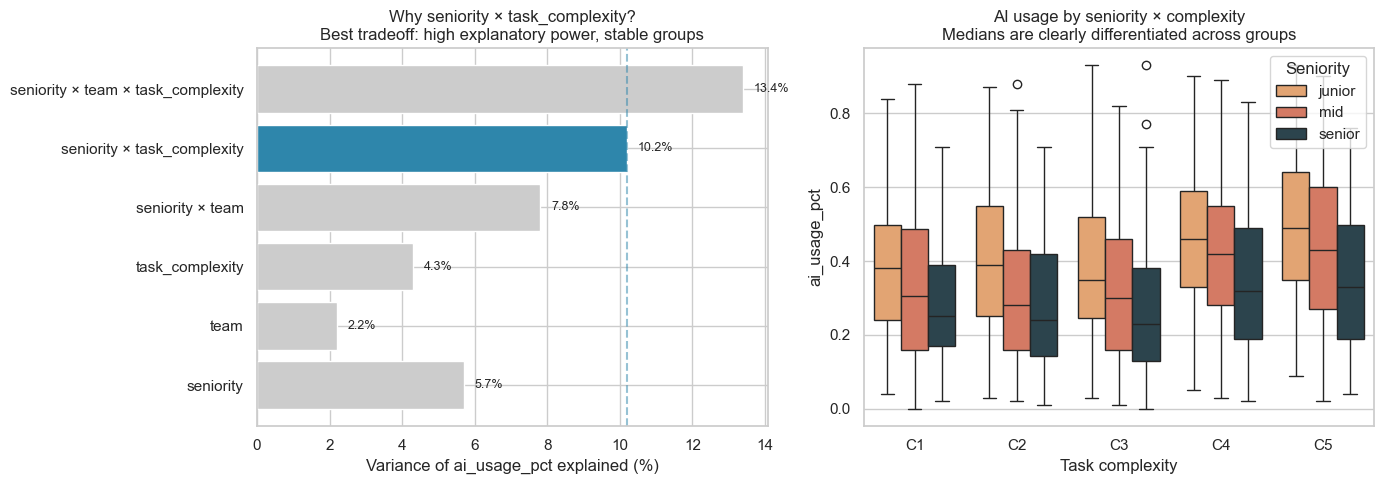

In [261]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: variance explained comparison ---
segmentations = {
    'seniority':                             0.057,
    'team':                                  0.022,
    'task_complexity':                       0.043,
    'seniority × team':                      0.078,
    'seniority × task_complexity':           0.102,
    'seniority × team × task_complexity':    0.134,
}
names = list(segmentations.keys())
values = [v * 100 for v in segmentations.values()]
colors = ['#cccccc' if n != 'seniority × task_complexity'
          else '#2E86AB' for n in names]

axes[0].barh(names, values, color=colors)
axes[0].set_xlabel('Variance of ai_usage_pct explained (%)')
axes[0].set_title('Why seniority × task_complexity?\nBest tradeoff: high explanatory power, stable groups')
axes[0].axvline(x=10.2, color='#2E86AB', linestyle='--', alpha=0.5)
for i, v in enumerate(values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# --- Right: distribution of ai_usage_pct by chosen segmentation ---
import seaborn as sns
plot_df = df.dropna(subset=['ai_usage_pct']).copy()
plot_df['complexity_label'] = 'C' + plot_df['task_complexity_score'].astype(str)

sns.boxplot(
    data=plot_df, x='complexity_label', y='ai_usage_pct', hue='seniority',
    hue_order=['junior', 'mid', 'senior'],
    order=['C1','C2','C3','C4','C5'],
    palette={'junior':'#F4A261','mid':'#E76F51','senior':'#264653'},
    ax=axes[1]
)
axes[1].set_xlabel('Task complexity')
axes[1].set_ylabel('ai_usage_pct')
axes[1].set_title('AI usage by seniority × complexity\nMedians are clearly differentiated across groups')
axes[1].legend(title='Seniority', loc='upper right')

plt.tight_layout()
plt.show()

### Reading the plot

The left panel ranks candidate segmentations by variance explained. Three observations drive the decision:

- `seniority × task_complexity_score` explains **10.2%** of the variance with only 15 groups and a minimum group size of 78 — plenty of data to stabilize each group median.
- The triple `seniority × team × task_complexity_score` edges higher at **13.4%**, but fragments the data into 60 groups with some cells down to 12 observations. The modest gain in explained variance isn't worth the instability in small groups.
- `team × seniority` — the initial candidate — reaches only **7.8%**. Team turns out to be a weaker discriminator than task complexity for AI usage.

The right panel confirms the choice is meaningful: median AI usage varies clearly both across seniority levels (juniors rely on AI more) and across complexity levels (simpler tasks get more AI help), and the boxes are well separated. Imputing with the group median will restore the right location for each missing value without injecting noise.


In [262]:
# ---------------------------------------------------------------
# Imputation of ai_usage_pct using seniority × task_complexity_score
# ---------------------------------------------------------------
group_cols = ['seniority', 'task_complexity_score']

# Compute group-wise medians on non-missing data
group_medians = (
    df.dropna(subset=['ai_usage_pct'])
      .groupby(group_cols)['ai_usage_pct']
      .median()
)

# Safety check: every (seniority, complexity) combination in the NaN rows
# must have a corresponding group median
nan_groups = df[df['ai_usage_pct'].isna()][group_cols].drop_duplicates()
missing_keys = [tuple(row) for row in nan_groups.values
                if tuple(row) not in group_medians.index]
assert not missing_keys, f"No group median available for: {missing_keys}"

# Apply imputation
nan_mask = df['ai_usage_pct'].isna()
df.loc[nan_mask, 'ai_usage_pct'] = (
    df.loc[nan_mask]
      .set_index(group_cols)
      .index
      .map(group_medians)
)

print(f"Imputed {nan_mask.sum()} records.")
print(f"Remaining missing: {df['ai_usage_pct'].isna().sum()}")
print(f"ai_usage_pct after imputation: {df['ai_usage_pct'].describe()}")


Imputed 143 records.
Remaining missing: 0
ai_usage_pct after imputation: count    3199.000000
mean        0.361110
std         0.195581
min         0.000000
25%         0.210000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64


### 4.20 - ai_assisted

Binary value. The logic is: if ai_usage_pct is above zero, the task was AI-assisted by definition, regardless of what the boolean flag says. We rebuild `ai_assisted` from the percentage rather than trust the self-reported flag, using the simple rule `ai_assisted = (ai_usage_pct > 0)`.


In [263]:
print(f"Null values: {df['ai_assisted'].isnull().sum()}")
print(f"\nValue counts:")
print(df['ai_assisted'].value_counts())

Null values: 0

Value counts:
ai_assisted
True     2522
False     677
Name: count, dtype: int64


In [264]:
# Step 1: surface the inconsistencies before fixing them
inconsistent_false = ((df['ai_assisted'] == False) & (df['ai_usage_pct'] > 0))
inconsistent_true  = ((df['ai_assisted'] == True)  & (df['ai_usage_pct'] == 0))

print(f"ai_assisted = False but ai_usage_pct > 0: {inconsistent_false.sum()}")
print(f"ai_assisted = True but ai_usage_pct = 0: {inconsistent_true.sum()}")
print(f"\nTotal inconsistencies: {inconsistent_false.sum() + inconsistent_true.sum()}")
print(f"Share of dataset affected: "
      f"{(inconsistent_false.sum() + inconsistent_true.sum()) / len(df) * 100:.1f}%")

# Step 2: rebuild ai_assisted from ai_usage_pct (the reliable source)
df['ai_assisted'] = df['ai_usage_pct'] > 0

# Step 3: verify consistency after the fix
remaining = ((df['ai_assisted'] == False) & (df['ai_usage_pct'] > 0)).sum() + \
            ((df['ai_assisted'] == True)  & (df['ai_usage_pct'] == 0)).sum()
print(f"\nAfter fix — ai_assisted distribution:")
print(df['ai_assisted'].value_counts())
print(f"Remaining inconsistencies: {remaining}")

ai_assisted = False but ai_usage_pct > 0: 675
ai_assisted = True but ai_usage_pct = 0: 0

Total inconsistencies: 675
Share of dataset affected: 21.1%

After fix — ai_assisted distribution:
ai_assisted
True     3197
False       2
Name: count, dtype: int64
Remaining inconsistencies: 0


`ai_assisted` is clean. Boolean, no nulls. 79% of tasks are AI-assisted. No cleaning needed.


### 4.21 - revisions

Number of revisions requested on the task.

In [265]:
print(f"Null values: {df['revisions'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['revisions'].describe())
print(f"\nValue counts:")
print(df['revisions'].value_counts().sort_index())

Null values: 0

Descriptive stats:
count    3199.000000
mean        3.010628
std         1.804521
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        11.000000
Name: revisions, dtype: float64

Value counts:
revisions
0     172
1     534
2     672
3     657
4     527
5     334
6     176
7      86
8      28
9       9
10      3
11      1
Name: count, dtype: int64


`revisions` is clean. Integer counts (0-11), no nulls. Median = 3 revisions, right-skewed with most tasks between 1-5. No cleaning needed.

### 4.22 - errors

Number of errors found in the task.

In [266]:
print(f"Null values: {df['errors'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['errors'].describe())
print(f"\nValue counts:")
print(df['errors'].value_counts().sort_index())

Null values: 0

Descriptive stats:
count    3199.000000
mean        1.016880
std         1.043622
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: errors, dtype: float64

Value counts:
errors
0    1205
1    1117
2     602
3     185
4      76
5      12
6       1
7       1
Name: count, dtype: int64


`errors` is clean. Integer counts (0-7), no nulls. 38% of tasks have zero errors, median = 1. No cleaning needed.


### 4.23 rework_hours 

Hours spent on rework. NON NELLE HOURS_SPENT SONO ORE IN PIU VEDIAMO
rework > hours spent ci può stare!!

In [267]:
print(f"Null values: {df['rework_hours'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['rework_hours'].describe())

mask = df['rework_hours'] > df['hours_spent']
print(f"\nRework > hours_spent: {mask.sum()} rows")

print(f"Negative rework_hours: {(df['rework_hours'] < 0).sum()}")

Null values: 71

Descriptive stats:
count    3128.000000
mean        2.436537
std         2.921570
min         0.000000
25%         1.110000
50%         1.810000
75%         2.950000
max        57.517012
Name: rework_hours, dtype: float64

Rework > hours_spent: 49 rows
Negative rework_hours: 0


`rework_hours` has 71 missing values (2.3% of the dataset). Unlike `hours_spent` or `billable_hours`, there is no mechanical anchor that deterministically links rework to another field, so before choosing an imputation strategy we need to understand *how much structure* there is in rework and *whether the missingness is systematic*. The figure below makes three diagnostic checks whose outcomes drive the decision.


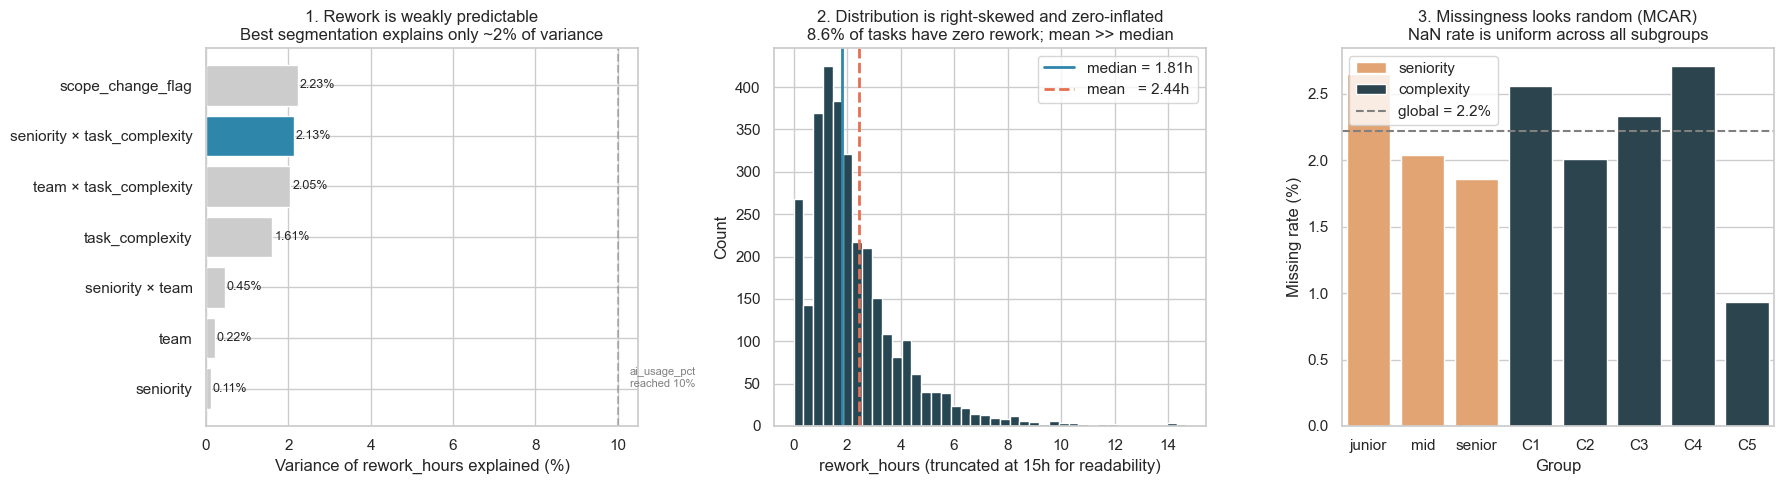

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Helper: variance explained by a grouping (analogue of eta^2)
def variance_explained(df, group_cols, target='rework_hours'):
    d = df.dropna(subset=[target] + group_cols)
    grand_mean = d[target].mean()
    total_ss   = ((d[target] - grand_mean) ** 2).sum()
    group_mean = d.groupby(group_cols)[target].transform('mean')
    within_ss  = ((d[target] - group_mean) ** 2).sum()
    return (total_ss - within_ss) / total_ss

# ---------- Evidence 1: how predictable is rework? ----------
segmentations = {
    'seniority':                         ['seniority'],
    'team':                              ['team'],
    'task_complexity':                   ['task_complexity_score'],
    'scope_change_flag':                 ['scope_change_flag'],
    'seniority × team':                  ['seniority', 'team'],
    'seniority × task_complexity':       ['seniority', 'task_complexity_score'],
    'team × task_complexity':            ['team', 'task_complexity_score'],
}
ve = pd.Series(
    {name: variance_explained(df, cols) * 100 for name, cols in segmentations.items()}
).sort_values()

# ---------- Evidence 2: distribution shape (skewed, zero-inflated) ----------
rw = df['rework_hours'].dropna()
median_rw = rw.median()
mean_rw   = rw.mean()
share_zero = (rw == 0).mean() * 100

# ---------- Evidence 3: are missing values random? ----------
nan_mask = df['rework_hours'].isna()
nan_by_sen = (
    pd.DataFrame({
        'nan_pct': df[nan_mask].groupby('seniority').size()
                    / df.groupby('seniority').size() * 100
    }).round(2)
)
nan_by_cpx = (
    pd.DataFrame({
        'nan_pct': df[nan_mask].groupby('task_complexity_score').size()
                    / df.groupby('task_complexity_score').size() * 100
    }).round(2)
)

# ---------- Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: variance explained — shows rework is hard to predict
colors = ['#2E86AB' if n == 'seniority × task_complexity' else '#cccccc' for n in ve.index]
axes[0].barh(ve.index, ve.values, color=colors)
axes[0].set_xlabel('Variance of rework_hours explained (%)')
axes[0].set_title('1. Rework is weakly predictable\nBest segmentation explains only ~2% of variance')
axes[0].axvline(x=10, linestyle='--', color='gray', alpha=0.5)
axes[0].text(10.3, 0, 'ai_usage_pct\nreached 10%', fontsize=8, color='gray', va='bottom')
for i, v in enumerate(ve.values):
    axes[0].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=9)

# Panel 2: distribution — shows skew and zero-inflation
axes[1].hist(rw[rw <= 15], bins=40, color='#264653', edgecolor='white')
axes[1].axvline(median_rw, color='#2E86AB', linestyle='-',  linewidth=2,
                label=f'median = {median_rw:.2f}h')
axes[1].axvline(mean_rw,   color='#E76F51', linestyle='--', linewidth=2,
                label=f'mean   = {mean_rw:.2f}h')
axes[1].set_xlabel('rework_hours (truncated at 15h for readability)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'2. Distribution is right-skewed and zero-inflated\n'
                  f'{share_zero:.1f}% of tasks have zero rework; mean >> median')
axes[1].legend()

# Panel 3: missingness rate across groups — shows MCAR-like pattern
sen_df = nan_by_sen.reset_index().rename(columns={'seniority': 'group'})
sen_df['dim'] = 'seniority'
cpx_df = nan_by_cpx.reset_index().rename(columns={'task_complexity_score': 'group'})
cpx_df['group'] = 'C' + cpx_df['group'].astype(str)
cpx_df['dim']   = 'complexity'
miss_df = pd.concat([sen_df, cpx_df])

sns.barplot(data=miss_df, x='group', y='nan_pct', hue='dim',
            palette={'seniority': '#F4A261', 'complexity': '#264653'},
            ax=axes[2])
axes[2].axhline(y=nan_mask.mean() * 100, linestyle='--', color='gray',
                label=f'global = {nan_mask.mean()*100:.1f}%')
axes[2].set_xlabel('Group')
axes[2].set_ylabel('Missing rate (%)')
axes[2].set_title('3. Missingness looks random (MCAR)\nNaN rate is uniform across all subgroups')
axes[2].legend()

plt.tight_layout()
plt.show()

### Reading the figure

**Panel 1 — Rework is weakly predictable.** The best segmentation (`seniority × task_complexity_score`) explains only ~2% of the variance in rework. The dashed line at 10% shows for reference how well `ai_usage_pct` was explained by the equivalent grouping: an order of magnitude more. Rework is dominated by task-level idiosyncrasy, not by structural features of the task or the person. This rules out regression-based or fine-grained group imputations — they would essentially collapse back onto the global central tendency with added noise.

**Panel 2 — The distribution is right-skewed and zero-inflated.** About 8% of tasks have exactly zero rework. Among the rest, the distribution has a long right tail: median 1.81h, mean 2.44h. The gap between mean and median is the signature of skewness. Imputing with the mean would inflate central-case values by dragging outliers into the estimate. The **median** is the robust choice.

**Panel 3 — The missing values look random.** NaN rates are essentially flat across seniority (2.0–2.7%) and complexity (0.9–2.7%) subgroups, clustered around the global rate of 2.3%. The missingness mechanism is plausibly MCAR (Missing Completely At Random) — likely logging oversights rather than a systematic pattern — which means any reasonable imputation will not introduce bias.

### Decision

Given low predictability, skewed distribution, and random missingness, an over-engineered imputation would offer marginal gain over a simple group median. We impute using the **median of `seniority × task_complexity_score`** — the same grouping used for `ai_usage_pct`, and the one with the highest (though modest) explanatory power for rework.


In [269]:
group_cols = ['seniority', 'task_complexity_score']

group_medians = (
    df.dropna(subset=['rework_hours'])
      .groupby(group_cols)['rework_hours']
      .median()
)

# Safety check: every (seniority, complexity) combo in NaN rows must have a median
nan_keys = df[df['rework_hours'].isna()][group_cols].drop_duplicates()
missing = [tuple(row) for row in nan_keys.values
           if tuple(row) not in group_medians.index]
assert not missing, f"No group median available for: {missing}"

nan_mask = df['rework_hours'].isna()
df.loc[nan_mask, 'rework_hours'] = (
    df.loc[nan_mask]
      .set_index(group_cols)
      .index
      .map(group_medians)
)

print(f"Imputed {nan_mask.sum()} records.")
print(f"Remaining missing in rework_hours: {df['rework_hours'].isna().sum()}")
print(f"rework_hours after imputation: {df['rework_hours'].describe()}")



Imputed 71 records.
Remaining missing in rework_hours: 0
rework_hours after imputation: count    3199.000000
mean        2.422300
std         2.890815
min         0.000000
25%         1.120000
50%         1.800000
75%         2.920000
max        57.517012
Name: rework_hours, dtype: float64


### 4.24 outcome_score

Quality/outcome score for the delivered task. 

In [270]:
print(f"Null values: {df['outcome_score'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['outcome_score'].describe())

print(f"\nTask status for rows with missing outcome_score:")
print(df[df['outcome_score'].isnull()]['task_status'].value_counts())

Null values: 132

Descriptive stats:
count    3067.000000
mean       68.877952
std        12.617015
min         9.000000
25%        60.890000
50%        69.410000
75%        77.640000
max       100.000000
Name: outcome_score, dtype: float64

Task status for rows with missing outcome_score:
task_status
review         38
delivered      38
in_progress    36
archived        9
draft           6
blocked         5
Name: count, dtype: int64


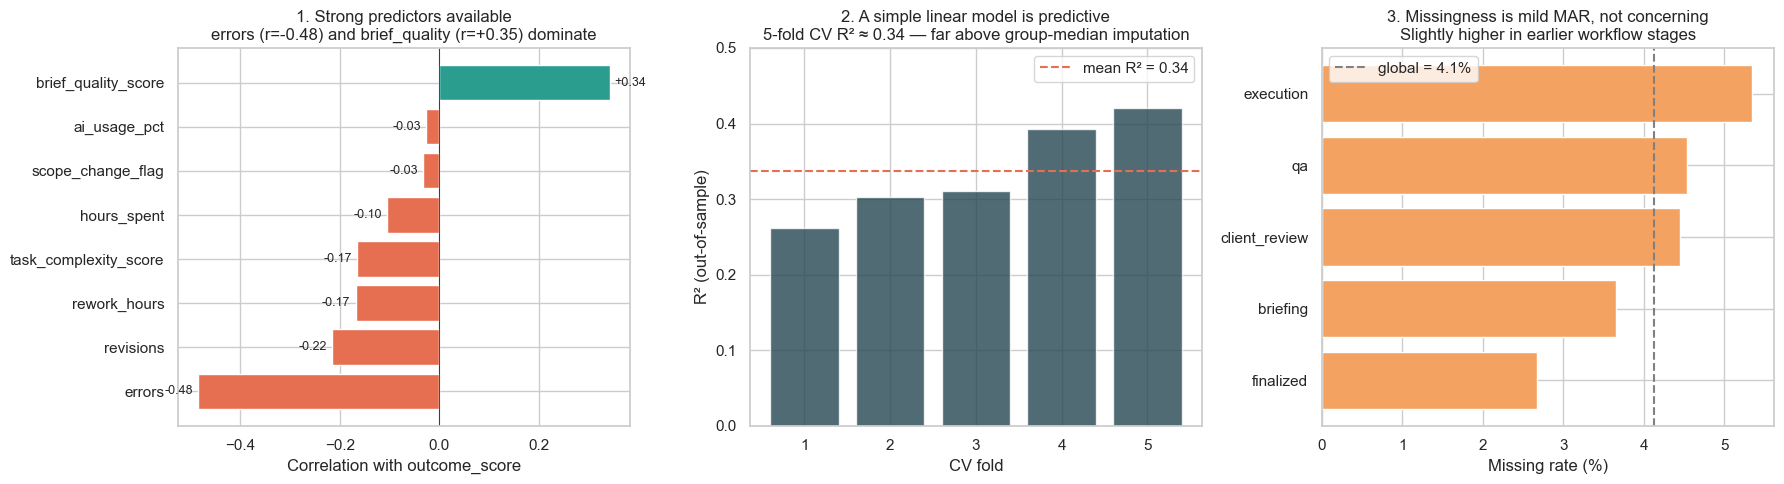

In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# ---------- Evidence 1: correlations with candidate predictors ----------
predictors = ['errors','brief_quality_score','revisions','rework_hours',
              'task_complexity_score','ai_usage_pct','hours_spent','scope_change_flag']
corrs = df[predictors + ['outcome_score']].corr()['outcome_score'] \
          .drop('outcome_score').sort_values()

# ---------- Evidence 2: predictive power of a simple linear model ----------
d = df.dropna(subset=predictors + ['outcome_score'])
X, y = d[predictors], d['outcome_score']
cv_r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

# ---------- Evidence 3: missingness pattern ----------
nan_mask = df['outcome_score'].isna()
miss_by_stage = (
    df[nan_mask].groupby('workflow_stage').size()
    / df.groupby('workflow_stage').size() * 100
).round(2).sort_values()

# ---------- Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: correlations with predictors
colors = ['#E76F51' if v < 0 else '#2A9D8F' for v in corrs.values]
axes[0].barh(corrs.index, corrs.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Correlation with outcome_score')
axes[0].set_title(f'1. Strong predictors available\n'
                  f'errors (r=-0.48) and brief_quality (r=+0.35) dominate')
for i, v in enumerate(corrs.values):
    axes[0].text(v + (0.01 if v>=0 else -0.01), i, f'{v:+.2f}',
                 va='center', ha='left' if v>=0 else 'right', fontsize=9)

# Panel 2: predictive power of a simple linear model
axes[1].bar(range(1, 6), cv_r2, color='#264653', alpha=0.8)
axes[1].axhline(cv_r2.mean(), linestyle='--', color='#E76F51',
                label=f'mean R² = {cv_r2.mean():.2f}')
axes[1].set_xlabel('CV fold')
axes[1].set_ylabel('R² (out-of-sample)')
axes[1].set_ylim(0, 0.5)
axes[1].set_title(f'2. A simple linear model is predictive\n'
                  f'5-fold CV R² ≈ {cv_r2.mean():.2f} — far above group-median imputation')
axes[1].legend()

# Panel 3: missingness pattern by workflow_stage
axes[2].barh(miss_by_stage.index, miss_by_stage.values, color='#F4A261')
axes[2].axvline(nan_mask.mean()*100, linestyle='--', color='gray',
                label=f'global = {nan_mask.mean()*100:.1f}%')
axes[2].set_xlabel('Missing rate (%)')
axes[2].set_title('3. Missingness is mild MAR, not concerning\n'
                  'Slightly higher in earlier workflow stages')
axes[2].legend()

plt.tight_layout()
plt.show()

### Reading the figure

**Panel 1 — Strong predictors available.** `outcome_score` has two dominant drivers: `errors` (r = −0.48) pushes outcomes down, `brief_quality_score` (r = +0.35) pushes them up. Both correlations are an order of magnitude stronger than anything we saw for `rework_hours`. Several secondary predictors (`revisions`, `rework_hours`, `task_complexity_score`) add incremental signal. This is not a variable driven by idiosyncratic noise — it has real structure we can exploit.

**Panel 2 — A simple linear model is predictive.** A plain linear regression on the available predictors achieves out-of-sample R² ≈ 0.35 (5-fold cross-validation). In other words, 35% of the variance in `outcome_score` is explained by fields already in the dataset. Imputing with a group median would throw this signal away: every imputed value would collapse toward the group average, ignoring the fact that a task with 4 errors and a poor brief has a *predictably* lower outcome than one with 0 errors and a great brief.

**Panel 3 — Missingness is mildly MAR, not concerning.** NaN rates range from 2.7% (finalized tasks) to 5.2% (tasks in execution). The mild gradient makes sense — `outcome_score` is recorded at closure, so it's more often missing for tasks that haven't reached the end. This is not MCAR but close enough that a well-specified predictive model will not introduce bias.

### Decision

Given predictable structure and strong correlations, we impute `outcome_score` using a **linear regression model** trained on records where the target is observed, then apply it to the missing cases. We clip predictions to the valid [0, 100] range since linear regression can in principle produce out-of-scale values.


In [272]:
predictors = ['errors','brief_quality_score','revisions','rework_hours',
              'task_complexity_score','ai_usage_pct','hours_spent','scope_change_flag']

# Safety check: predictors must be complete for all rows we want to impute
nan_mask = df['outcome_score'].isna()
assert df.loc[nan_mask, predictors].notna().all().all(), \
       "Some records needing imputation have missing predictors."

# Train on observed data, predict on missing
train = df.dropna(subset=predictors + ['outcome_score'])
model = LinearRegression().fit(train[predictors], train['outcome_score'])

predicted = model.predict(df.loc[nan_mask, predictors])
df.loc[nan_mask, 'outcome_score'] = np.clip(predicted, 0, 100)

print(f"Imputed {nan_mask.sum()} records.")
print(f"Predicted outcome_score range: "
      f"[{predicted.min():.2f}, {predicted.max():.2f}]")
print(f"Remaining missing in outcome_score: {df['outcome_score'].isna().sum()}")

print(f"outcome_score after imputation: {df['outcome_score'].describe()}")


Imputed 132 records.
Predicted outcome_score range: [39.27, 83.70]
Remaining missing in outcome_score: 0
outcome_score after imputation: count    3199.000000
mean       68.920454
std        12.450079
min         9.000000
25%        61.140000
50%        69.510000
75%        77.322394
max       100.000000
Name: outcome_score, dtype: float64


Note: we use a linear model rather than a more complex one (Random Forest, KNN) deliberately. With only 132 records to impute and R² ≈ 0.35 already achievable linearly, a more sophisticated model would add opacity without meaningful gain. The linear coefficients also double as a sanity check — their signs should match the correlations shown in Panel 1.


### 4.25 revenue

Revenue generated by each task. This is a critical financial variable that, together with cost and profit, determines margins.

### 4.26 cost

Total operating cost for the task (personnel, overhead, tools).

### 4.27 profit 

Net profit for the task (revenue - cost).

### 4.28 created_by 

User ID of the person who created the task record.

In [273]:
print(f"Null values: {df['created_by'].isnull().sum()}")
print(f"\nUnique users: {df['created_by'].nunique()}")

print(df['created_by'].value_counts())


Null values: 0

Unique users: 119
created_by
user_026    44
user_087    40
user_028    38
user_070    37
user_012    37
            ..
user_084    18
user_118    18
user_093    17
user_027    15
user_088    15
Name: count, Length: 119, dtype: int64


### 4.29 updated_at

Timestamp of the last update to the task record.

In [274]:
print(f"Null values: {df['updated_at'].isnull().sum()}")

print(f"\nData type: {df['updated_at'].dtype}")
print(f"\nSample values (first 5):")
print(df['updated_at'].head())

if df['updated_at'].dtype == 'object':
    df['updated_at'] = pd.to_datetime(df['updated_at'])
    print(f"\n✓ Parsed to datetime")

print(f"\nDate range:")
print(f"  Earliest: {df['updated_at'].min()}")
print(f"  Latest: {df['updated_at'].max()}")
print(f"  Span: {(df['updated_at'].max() - df['updated_at'].min()).days} days")

Null values: 0

Data type: object

Sample values (first 5):
0    2025-11-28
1    2026-01-26
2    2025-09-17
3    2025-11-12
4    2026-05-09
Name: updated_at, dtype: object

✓ Parsed to datetime

Date range:
  Earliest: 2025-07-01 00:00:00
  Latest: 2026-06-03 00:00:00
  Span: 337 days


### Validating date consistency with a swap test

Before any time-based analysis, we need the three date fields — `created_at`, `delivered_at`, `updated_at` — to respect basic causal ordering. We check three rules:

- **R1**: `created_at ≤ updated_at` — a record cannot be updated before it's created.
- **R2**: `created_at ≤ delivered_at` — a task cannot be delivered before it's created.
- **R3**: `updated_at` vs. `delivered_at` — not strictly ordered, since `updated_at` reflects the last record modification, which can happen before the planned delivery.


In [275]:
df['created_at']   = pd.to_datetime(df['created_at'],   errors='coerce')
df['delivered_at'] = pd.to_datetime(df['delivered_at'], errors='coerce')
df['updated_at']   = pd.to_datetime(df['updated_at'],   errors='coerce')

r1 = ((df['created_at'] > df['updated_at'])
      & df['created_at'].notna() & df['updated_at'].notna())
r2 = ((df['created_at'] > df['delivered_at'])
      & df['created_at'].notna() & df['delivered_at'].notna())

print(f"R1 violations (created > updated):   {r1.sum()}")
print(f"R2 violations (created > delivered): {r2.sum()}")

R1 violations (created > updated):   0
R2 violations (created > delivered): 14


R1 has zero violations — `updated_at` is always consistent with creation. R2 has **14 violations**: tasks apparently delivered *before* being created, which is physically impossible. These 14 records are the focus of the rest of this section.

### Why the naive fix is wrong

The obvious approach — "reset `delivered_at = created_at + sla_days`" — forces `sla_breach = 0` on all 14 records. But the data tells us **8 of the 14 records have `sla_breach = 1` recorded**. Overwriting their `delivered_at` would silently discard that information, so we need something smarter.

### The swap hypothesis

A more plausible explanation is that the two dates were **swapped during data entry**: the system wrote `delivered_at` where `created_at` should have gone and vice versa. If that's true, then taking the absolute difference `|created_at − delivered_at|` gives the correct `actual_days`, which should be consistent with `sla_days` and `sla_breach`:

- If `actual_days ≤ sla_days` → expected `sla_breach = 0`
- If `actual_days > sla_days`  → expected `sla_breach = 1`

When the implied breach matches the observed one, the swap hypothesis is validated for that record. When it doesn't, something deeper is corrupted and a simple swap cannot recover it.


In [276]:
anom = df[r2].copy()
anom['actual_if_swapped'] = (anom['created_at'] - anom['delivered_at']).dt.days
anom['implied_breach']    = (anom['actual_if_swapped'] > anom['sla_days']).astype(int)
anom['consistent']        = (anom['implied_breach'] == anom['sla_breach'])

print(anom[['task_id','created_at','delivered_at',
            'actual_if_swapped','sla_days','sla_breach',
            'implied_breach','consistent']].to_string(index=False))
print(f"\nConsistent with swap hypothesis: "
      f"{anom['consistent'].sum()} / {len(anom)}")

task_id created_at delivered_at  actual_if_swapped  sla_days  sla_breach  implied_breach  consistent
 T00089 2025-10-06   2025-10-05                  1       7.0           0               0        True
 T00403 2026-02-09   2026-02-08                  1       3.0           1               0       False
 T00878 2026-03-29   2026-03-26                  3       2.0           1               1        True
 T01083 2025-11-13   2025-11-12                  1       3.0           0               0        True
 T01112 2025-12-06   2025-12-05                  1       3.0           1               0       False
 T01163 2026-05-03   2026-04-30                  3       2.0           1               1        True
 T01169 2026-01-21   2026-01-20                  1       5.0           0               0        True
 T01230 2026-04-20   2026-04-17                  3      10.0           0               0        True
 T02127 2026-05-01   2026-04-30                  1       5.0           1               0   

### Visualizing the split

A single chart makes the two groups visible: the swap-implied `actual_days` vs. the SLA threshold, colored by the recorded `sla_breach`.


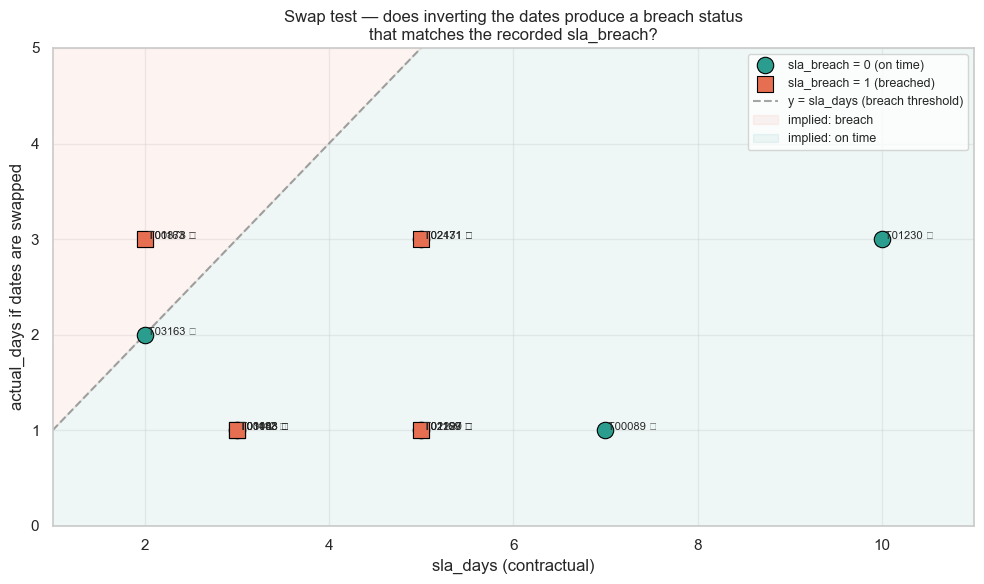

In [277]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for breach, marker, color, label in [
    (0, 'o', '#2A9D8F', 'sla_breach = 0 (on time)'),
    (1, 's', '#E76F51', 'sla_breach = 1 (breached)'),
]:
    sub = anom[anom['sla_breach'] == breach]
    ax.scatter(sub['sla_days'], sub['actual_if_swapped'],
               marker=marker, color=color, s=140, edgecolor='black',
               linewidth=0.8, label=label, zorder=3)

# Diagonal y = sla_days: above = breach expected, below = on-time expected
x_line = np.linspace(1, 11, 50)
ax.plot(x_line, x_line, linestyle='--', color='gray', alpha=0.7,
        label='y = sla_days (breach threshold)')
ax.fill_between(x_line, x_line, 12, color='#E76F51', alpha=0.08,
                label='implied: breach')
ax.fill_between(x_line, 0, x_line, color='#2A9D8F', alpha=0.08,
                label='implied: on time')

# Annotate each record
for _, row in anom.iterrows():
    ok = '✓' if row['consistent'] else '✗'
    ax.annotate(f" {row['task_id']} {ok}",
                (row['sla_days'], row['actual_if_swapped']),
                fontsize=8)

ax.set_xlabel('sla_days (contractual)')
ax.set_ylabel('actual_days if dates are swapped')
ax.set_title('Swap test — does inverting the dates produce a breach status\n'
             'that matches the recorded sla_breach?')
ax.set_xlim(1, 11)
ax.set_ylim(0, 5)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the plot

Each point is one of the 14 anomalous records. The x-axis shows the contractual SLA; the y-axis shows the `actual_days` we'd get if we swapped the two dates. The diagonal line splits the plane into "implied on-time" (below) and "implied breach" (above). A point is **consistent with the swap hypothesis** when its color matches the region it lands in:

- Green circles below the diagonal → on-time implied, `sla_breach = 0` recorded ✓
- Red squares above the diagonal → breach implied, `sla_breach = 1` recorded ✓
- Red squares below the diagonal → inconsistent: the swap would produce an on-time delivery, but the record says it breached ✗

The 8 consistent records cluster correctly in their expected regions. The 6 inconsistent ones are all red squares in the green region — they claim to have breached SLA despite an implied delivery well within the contractual window. For these, the swap cannot explain what's corrupted: it could be both dates, it could be `sla_breach` itself, or the actual delivery happened after a formal one that wasn't tracked. We can't distinguish these hypotheses from the available data.

### Action

Given the two groups behave differently, we treat them differently: **swap the dates for the 8 consistent records**, **drop the 6 ambiguous ones**. Dropping six records (0.2% of the dataset) is a negligible cost compared to fabricating dates on rows where we know something structural is wrong.


In [ ]:
consistent_ids   = anom.loc[ anom['consistent'], 'task_id'].values
inconsistent_ids = anom.loc[~anom['consistent'], 'task_id'].values

# 1. Swap dates for the 8 consistent records
swap_mask = df['task_id'].isin(consistent_ids)
df.loc[swap_mask, ['created_at', 'delivered_at']] = \
    df.loc[swap_mask, ['delivered_at', 'created_at']].values

# 2. Drop the 6 records that cannot be reconciled
df = df[~df['task_id'].isin(inconsistent_ids)].copy()

# 3. Verify the fix
remaining_r2 = ((df['created_at'] > df['delivered_at'])
                & df['created_at'].notna()
                & df['delivered_at'].notna()).sum()
print(f"Swapped: {len(consistent_ids)} records")
print(f"Dropped: {len(inconsistent_ids)} records")
print(f"Remaining R2 violations: {remaining_r2}")
print(f"Dataset size after date cleanup: {len(df)}")

# 4. Compute actual delivery time as a clean downstream feature
df['actual_days'] = (df['delivered_at'] - df['created_at']).dt.days
print(f"\nactual_days: min={df['actual_days'].min()}, "
      f"median={df['actual_days'].median()}, "
      f"max={df['actual_days'].max()}")



Swapped: 8 records
Dropped: 6 records
Remaining R2 violations: 0
Dataset size after date cleanup: 3193

actual_days: min=0, median=5.0, max=10
R2 violations (created > delivered): 14


### 4.30 task_status

Current status of the task in the workflow.

In [279]:
print(f"Null values: {df['task_status'].isnull().sum()}")
print(f"Null %: {df['task_status'].isnull().mean()*100:.2f}%")
print(f"\nUnique statuses: {df['task_status'].nunique()}")
print(f"\nStatus distribution:")
print(df['task_status'].value_counts())

print(f"\n\nConsistency check with delivered_at:")
print(f"Status = 'delivered' but delivered_at is NULL:")
delivered_no_date = df[(df['task_status'] == 'delivered') & (df['delivered_at'].isnull())]
print(f"  {len(delivered_no_date)} rows ")

print(f"\nStatus ≠ 'delivered' but delivered_at is NOT NULL:")
not_delivered_has_date = df[(df['task_status'] != 'delivered') & (df['delivered_at'].notnull())]
print(f"  {len(not_delivered_has_date)} rows")

Null values: 0
Null %: 0.00%

Unique statuses: 6

Status distribution:
task_status
in_progress    1107
review          855
delivered       754
draft           179
blocked         149
archived        149
Name: count, dtype: int64


Consistency check with delivered_at:
Status = 'delivered' but delivered_at is NULL:
  0 rows 

Status ≠ 'delivered' but delivered_at is NOT NULL:
  2439 rows


### 4.31 workflow_stage

Current stage in the task workflow.

In [280]:
print(f"Null values: {df['workflow_stage'].isnull().sum()}")
print(f"\nUnique stages: {df['workflow_stage'].nunique()}")
print(f"\nStage distribution:")
print(df['workflow_stage'].value_counts())

Null values: 0

Unique stages: 5

Stage distribution:
workflow_stage
qa               680
client_review    650
finalized        636
briefing         629
execution        598
Name: count, dtype: int64


### 4.32 jira_ticket

JIRA ticket ID associated with the task.

In [281]:
print(f"Null values: {df['jira_ticket'].isnull().sum()}")
print(f"\nUnique tickets: {df['jira_ticket'].nunique()}")
print(f"\nData type: {df['jira_ticket'].dtype}")
print(f"\nSample values (first 10 non-null):")
print(df[df['jira_ticket'].notnull()]['jira_ticket'].head(10).tolist())


Null values: 331

Unique tickets: 2822

Data type: object

Sample values (first 10 non-null):
['JIRA-49014', 'JIRA-84793', 'JIRA-42485', 'JIRA-53111', 'JIRA-86006', 'JIRA-60375', 'JIRA-11083', 'JIRA-78764', 'JIRA-77681', 'JIRA-82158']


### 4.33 legacy_ai_flag

Flag indicating if the task used legacy AI tools (vs modern AI).

In [282]:
print(f"Null values: {df['legacy_ai_flag'].isnull().sum()}")

print(f"\nUnique values: {df['legacy_ai_flag'].nunique()}")
print(f"\nValue distribution:")
print(df['legacy_ai_flag'].value_counts())
print(f"\nData type: {df['legacy_ai_flag'].dtype}")

# Check relationship with ai_assisted
print(f"\n\nCross-tabulation with ai_assisted:")
print(pd.crosstab(df['legacy_ai_flag'], df['ai_assisted'], margins=True))

# AI usage % for legacy vs non-legacy
print(f"\n\nAI usage by legacy flag:")
print(df.groupby('legacy_ai_flag')['ai_usage_pct'].agg(['count', 'mean', 'median']))

Null values: 0

Unique values: 3

Value distribution:
legacy_ai_flag
false      1433
true       1425
unknown     335
Name: count, dtype: int64

Data type: object


Cross-tabulation with ai_assisted:
ai_assisted     False  True   All
legacy_ai_flag                   
false               2  1431  1433
true                0  1425  1425
unknown             0   335   335
All                 2  3191  3193


AI usage by legacy flag:
                count      mean  median
legacy_ai_flag                         
false            1433  0.356755    0.35
true             1425  0.364642    0.34
unknown           335  0.364343    0.35


### 4.34 content_version

Version of the content/deliverable.

In [283]:
print(f"Null values: {df['content_version'].isnull().sum()}")
print(f"Null %: {df['content_version'].isnull().mean()*100:.2f}%")
print(f"\nUnique versions: {df['content_version'].nunique()}")
print(f"\nVersion distribution:")
print(df['content_version'].value_counts().sort_index())
print(f"\nData type: {df['content_version'].dtype}")

print(f"\n\nRelationship with revisions:")
print(df.groupby('content_version')['revisions'].agg(['count', 'mean', 'median']))

print(f"\n\nRelationship with rework_hours:")
print(df.groupby('content_version')['rework_hours'].agg(['count', 'mean', 'median']))

Null values: 0
Null %: 0.00%

Unique versions: 5

Version distribution:
content_version
final    551
v1       908
v2       768
v3       653
v4       313
Name: count, dtype: int64

Data type: object


Relationship with revisions:
                 count      mean  median
content_version                         
final              551  2.978221     3.0
v1                 908  3.091410     3.0
v2                 768  3.044271     3.0
v3                 653  2.973966     3.0
v4                 313  2.798722     3.0


Relationship with rework_hours:
                 count      mean  median
content_version                         
final              551  2.602238    1.83
v1                 908  2.327501    1.83
v2                 768  2.383021    1.80
v3                 653  2.459011    1.80
v4                 313  2.414828    1.68
